## Import libraries

In [1]:
from pathlib import Path
import os, sys

project_root = Path.cwd().parent.parent
sys.path.append(str(project_root))
os.chdir(project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display, Markdown
import warnings
warnings.filterwarnings('ignore')

from fmu2ml.analysis.spatial_correlation import (
    TemperatureGradientAnalyzer,
    LoadPropagationAnalyzer,
    SpatialCorrelationAnalyzer
)

from raps.config import ConfigManager

sns.set_style("whitegrid")
%matplotlib inline

print("✓ Imports complete")

✓ Imports complete


## Define Parameters

In [ ]:
# Configuration
SYSTEM_NAME = 'lassen'

config = ConfigManager(system_name=SYSTEM_NAME).get_config()
NUM_CDUS = config['NUM_CDUS']


# Data paths
DATA_PATH = f'../data/{SYSTEM_NAME}/systematic/systematic_fmu_output_3.8hrs.parquet'

# DATA_PATH = '../data/marconi/chunk_0/fmu_output_24.0hrs_operational.parquet'
OUTPUT_DIR_BASE = f'../results/{SYSTEM_NAME}/data_analysis/spatial_correlation'
LOAD_PROPAGATION_DIR = f'{OUTPUT_DIR_BASE}/load_propagation'
TEMPERATURE_GRADIENT_DIR = f'{OUTPUT_DIR_BASE}/temperature_gradient'
BASIC_CORRELATION_DIR = f'{OUTPUT_DIR_BASE}/basic_correlations'

# Create output directories
os.makedirs(LOAD_PROPAGATION_DIR, exist_ok=True)
os.makedirs(TEMPERATURE_GRADIENT_DIR, exist_ok=True)
os.makedirs(BASIC_CORRELATION_DIR, exist_ok=True)

# Analysis parameters
SAMPLE_SIZE = None  # None for full dataset, or specify number for testing
N_WORKERS = 49  #  to suit the marconi perfectly

print(f"System: {SYSTEM_NAME}")
print(f"Number of CDUs: {NUM_CDUS}")
print(f"Data path: {DATA_PATH}")
print(f"Output directories created")
print(f"Sample size: {'Full dataset' if SAMPLE_SIZE is None else SAMPLE_SIZE}")
print(f"Workers: {N_WORKERS}")

System: lassen
Number of CDUs: 44
Data path: ../data/lassen/systematic/systematic_fmu_output_3.8hrs.parquet
Output directories created
Sample size: Full dataset
Workers: 49


## Load Data

In [3]:
# # Load Data
# print("Loading data for preview...")
# df = pd.read_parquet(DATA_PATH)

# if SAMPLE_SIZE:
#     df = df.iloc[:SAMPLE_SIZE]

# print(f"Data shape: {df.shape}")
# print(f"Timesteps: {len(df)}")
# print("\nColumn sample:")
# print(df.columns[:10].tolist())

In [4]:
# Input ranges
INPUT_RANGES = {
    'Q_flow': (config.get('MIN_POWER'), config.get('MAX_POWER')),    # kW
    'T_Air': (288.15, 308.15),   # K
    'T_ext': (283.15, 313.15)    # K
}

## Create Analysis Data

In [6]:
import pandas as pd
import numpy as np

def generate_cooling_input_data(
    num_cdus,
    rows=100,
    
    # Initial/baseline values
    q_flow_baseline=20000,      # Baseline heat load in W (or kW depending on your scale)
    t_air_baseline=295.15,      # Baseline air temperature ~22°C in Kelvin
    t_ext_baseline=288.15,      # Baseline external temperature ~15°C in Kelvin
    
    # Limits
    limits={
        'Q_flow': (1000, 35000),
        'T_Air': (273.15, 308.15),
        'T_ext': (273.15, 313.15)
    },
    
    # Hotspot configuration
    num_hotspots=5,
    hotspot_load_range=(0.75, 0.95),
    hotspot_indices=None,  # List of CDU indices (1-based) to be hotspots, or None for random
    
    # Temperature sinusoidal configuration
    t_air_amplitude=5.0,        # Amplitude in Kelvin
    t_air_noise_std=0.8,        # Noise standard deviation in Kelvin
    t_air_cycles=2,             # Number of sinusoidal cycles
    
    t_ext_amplitude=8.0,        # External temp has larger diurnal swing
    t_ext_noise_std=1.0,
    t_ext_cycles=1,             # Typically 1 cycle = 1 day pattern
    
    # Random seed for reproducibility
    random_seed=None
):
    """
    Generate datacenter cooling simulation input data with:
    - Hotspots: CDUs with consistently high thermal load
    - Sinusoidal temperatures: Realistic diurnal temperature patterns with noise
    
    Parameters:
    -----------
    num_cdus : int
        Number of CDUs (49-257 based on your config)
    rows : int
        Number of time steps/rows to generate
    q_flow_baseline : float
        Baseline heat load for non-hotspot CDUs
    t_air_baseline : float
        Baseline inlet air temperature (Kelvin)
    t_ext_baseline : float
        Baseline external temperature (Kelvin)
    limits : dict
        Min/max limits for Q_flow, T_Air, T_ext
    num_hotspots : int
        Number of hotspot CDUs (4-5 as requested)
    hotspot_load_range : tuple
        (min, max) fraction of max Q_flow for hotspots
    hotspot_indices : list or None
        Specific CDU indices (1-based) to be hotspots, None for random selection
    t_air_amplitude : float
        Amplitude of T_Air sine wave (Kelvin)
    t_air_noise_std : float
        Standard deviation of T_Air noise (Kelvin)
    t_air_cycles : float
        Number of sine wave cycles for T_Air
    t_ext_amplitude : float
        Amplitude of T_ext sine wave (Kelvin)
    t_ext_noise_std : float
        Standard deviation of T_ext noise (Kelvin)
    t_ext_cycles : float
        Number of sine wave cycles for T_ext
    random_seed : int or None
        Random seed for reproducibility
    
    Returns:
    --------
    pd.DataFrame
        Generated input data with proper column naming
    """
    
    if random_seed is not None:
        np.random.seed(random_seed)
    
    df = pd.DataFrame()
    
    # Get limits
    q_min, q_max = limits['Q_flow']
    t_air_min, t_air_max = limits['T_Air']
    t_ext_min, t_ext_max = limits['T_ext']
    
    # ============ DETERMINE HOTSPOT CDUs ============
    cdu_indices = list(range(1, num_cdus + 1))  # 1-based indexing
    
    if hotspot_indices is not None:
        hotspot_cdus = set(hotspot_indices)
    else:
        actual_num_hotspots = min(num_hotspots, num_cdus)
        hotspot_cdus = set(np.random.choice(cdu_indices, size=actual_num_hotspots, replace=False))
    
    # ============ TIME VECTOR FOR SINUSOIDAL PATTERNS ============
    t = np.linspace(0, 2 * np.pi, rows)
    
    # Random phase shifts
    phase_ext = np.random.uniform(0, 2 * np.pi)
    
    # ============ GENERATE T_ext (SINGLE COLUMN) ============
    t_ext_col = 'simulator_1_centralEnergyPlant_1_coolingTowerLoop_1_sources_T_ext'
    t_ext_values = _generate_sinusoidal_temp(
        rows=rows,
        t=t * t_ext_cycles,
        baseline=t_ext_baseline,
        amplitude=t_ext_amplitude,
        noise_std=t_ext_noise_std,
        phase=phase_ext,
        temp_min=t_ext_min,
        temp_max=t_ext_max
    )
    df[t_ext_col] = t_ext_values
    
    # ============ GENERATE PER-CDU FEATURES ============
    for cdu_idx in cdu_indices:
        # Q_flow column
        q_flow_col = f'simulator_1_datacenter_1_computeBlock_{cdu_idx}_cabinet_1_sources_Q_flow_total'
        
        # T_Air column  
        t_air_col = f'simulator_1_datacenter_1_computeBlock_{cdu_idx}_cabinet_1_sources_T_Air'
        
        # Generate Q_flow values
        if cdu_idx in hotspot_cdus:
            q_flow_values = _generate_hotspot_qflow(
                rows=rows,
                q_min=q_min,
                q_max=q_max,
                load_range=hotspot_load_range
            )
        else:
            q_flow_values = _generate_normal_qflow(
                rows=rows,
                baseline=q_flow_baseline,
                q_min=q_min,
                q_max=q_max
            )
        
        # Generate T_Air values (sinusoidal with per-CDU phase variation)
        # Each CDU has slightly different phase to simulate spatial variation
        phase_air = np.random.uniform(0, 2 * np.pi)
        
        # T_Air can also be influenced by Q_flow (higher load = higher temp)
        # Add correlation factor
        q_flow_normalized = (q_flow_values - q_min) / (q_max - q_min)
        load_temp_offset = q_flow_normalized * 3.0  # Up to 3K higher for high loads
        
        t_air_values = _generate_sinusoidal_temp(
            rows=rows,
            t=t * t_air_cycles,
            baseline=t_air_baseline,
            amplitude=t_air_amplitude,
            noise_std=t_air_noise_std,
            phase=phase_air,
            temp_min=t_air_min,
            temp_max=t_air_max,
            offset=load_temp_offset
        )
        
        df[q_flow_col] = q_flow_values
        df[t_air_col] = t_air_values
    
    # Store metadata
    df.attrs['hotspot_cdus'] = list(hotspot_cdus)
    df.attrs['num_cdus'] = num_cdus
    df.attrs['hotspot_q_flow_columns'] = [
        f'simulator_1_datacenter_1_computeBlock_{idx}cabinet_1_sources_Q_flow_total' 
        for idx in hotspot_cdus
    ]
    
    return df


def _generate_hotspot_qflow(rows, q_min, q_max, load_range):
    """
    Generate consistently high Q_flow values for hotspot CDUs.
    """
    # Hotspots operate at high load fraction
    load_fraction = np.random.uniform(load_range[0], load_range[1])
    high_load = q_min + (q_max - q_min) * load_fraction
    
    # Small fluctuations (±5% of value) - hotspots are consistently high but not constant
    noise_std = high_load * 0.05
    noise = np.random.normal(0, noise_std, rows)
    
    # Slight slow drift (simulating workload changes)
    drift = np.cumsum(np.random.normal(0, noise_std * 0.01, rows))
    drift = drift - drift.mean()
    
    values = high_load + noise + drift
    return np.clip(values, q_min, q_max)


def _generate_normal_qflow(rows, baseline, q_min, q_max):
    """
    Generate normal (non-hotspot) Q_flow values with moderate variation.
    """
    # Normal CDUs have more variable load
    noise_std = baseline * 0.15
    noise = np.random.normal(0, noise_std, rows)
    
    # Add some random walk behavior
    drift = np.cumsum(np.random.normal(0, noise_std * 0.02, rows))
    drift = drift - drift.mean()
    
    # Occasional load changes (step patterns)
    step_changes = np.zeros(rows)
    num_steps = np.random.randint(1, 4)
    step_positions = np.random.choice(rows, size=num_steps, replace=False)
    for pos in step_positions:
        step_magnitude = np.random.uniform(-0.02, 0.03) * baseline
        step_changes[pos:] += step_magnitude
    
    values = baseline + noise + drift + step_changes
    return np.clip(values, q_min, q_max)


def _generate_sinusoidal_temp(rows, t, baseline, amplitude, noise_std, phase, 
                               temp_min, temp_max, offset=None):
    """
    Generate sinusoidal temperature pattern with noise and optional offset.
    """
    # Base sinusoidal pattern
    sinusoid = amplitude * np.sin(t + phase)
    
    # Gaussian noise
    noise = np.random.normal(0, noise_std, rows)
    
    # Slow-varying bias (random walk component for weather patterns)
    bias_drift = np.cumsum(np.random.normal(0, 0.05, rows))
    bias_drift = bias_drift - bias_drift.mean()
    bias_drift = np.clip(bias_drift, -amplitude * 0.5, amplitude * 0.5)
    
    # Combine components
    values = baseline + sinusoid + noise + bias_drift
    
    # Add optional offset (e.g., from heat load correlation)
    if offset is not None:
        values = values + offset
    
    return np.clip(values, temp_min, temp_max)


# ============ CONVENIENCE FUNCTION TO CREATE vals_dict ============
def create_vals_dict(num_cdus, q_flow_initial=20000, t_air_initial=295.15, t_ext_initial=288.15):
    """
    Create initial values dictionary with proper naming convention.
    
    Parameters:
    -----------
    num_cdus : int
        Number of CDUs
    q_flow_initial : float
        Initial Q_flow value for all CDUs
    t_air_initial : float
        Initial T_Air value for all CDUs
    t_ext_initial : float
        Initial T_ext value
    
    Returns:
    --------
    dict
        Dictionary with proper column names and initial values
    """
    vals_dict = {}
    
    # T_ext (single value)
    vals_dict['simulator_1_centralEnergyPlant_1_coolingTowerLoop_1_sources_T_ext'] = t_ext_initial
    
    # Per-CDU values
    for cdu_idx in range(1, num_cdus + 1):
        q_flow_col = f'simulator_1_datacenter_1_computeBlock_{cdu_idx}cabinet_1_sources_Q_flow_total'
        t_air_col = f'simulator_1_datacenter_1_computeBlock{cdu_idx}_cabinet_1_sources_T_Air'
        
        vals_dict[q_flow_col] = q_flow_initial
        vals_dict[t_air_col] = t_air_initial
    
    return vals_dict


In [7]:
# Generate data
df_input = generate_cooling_input_data(
    num_cdus=NUM_CDUS,
    rows=3600*5,
    
    # Baseline values
    q_flow_baseline=20000,
    t_air_baseline=295.15,  # ~22°C
    t_ext_baseline=288.15,  # ~15°C
    
    # Hotspot config
    num_hotspots=10,
    hotspot_load_range=(0.80, 0.95),
    hotspot_indices=[1, 5, 12, 25, 40], # or None
    
    # Temperature sinusoidal config
    t_air_amplitude=10.0,
    t_air_noise_std=0.05,
    t_air_cycles=15,
    
    t_ext_amplitude=12.0,
    t_ext_noise_std=0.08,
    t_ext_cycles=3,
    
    random_seed=42
)

In [8]:
from fmu2ml.simulation import fmu_simulator
sim = fmu_simulator.FMUSimulator(system_name='lassen')

Initializing FMU...


2026-02-12 10:22:49 - fmu2ml.simulation.fmu_simulator - INFO - ✓ FMU simulator initialized for lassen
2026-02-12 10:22:49 - fmu2ml.simulation.fmu_simulator - INFO - NUM_CDUS: 44


RK-method: sdirk34hw
Local extrapolation
FSAL
Continuous extension


In [9]:
df_sim = sim.run_simulation(stabilization_hours=3, input_data=df_input,step_size=1)

Initializing FMU...


2026-02-12 10:23:02 - fmu2ml.simulation.fmu_simulator - INFO - FMU reset to initial state
2026-02-12 10:23:02 - fmu2ml.simulation.fmu_simulator - INFO - Starting stabilization (max 3 hours)...


RK-method: sdirk34hw
Local extrapolation
FSAL
Continuous extension


2026-02-12 10:25:00 - fmu2ml.simulation.fmu_simulator - WARNING - Max stabilization time (3 hours) reached
2026-02-12 10:25:00 - fmu2ml.simulation.fmu_simulator - INFO - Running operational simulation for 18000 steps...
2026-02-12 10:36:36 - fmu2ml.simulation.fmu_simulator - INFO - Progress: 9000/18000 steps (50.0%)
2026-02-12 10:48:07 - fmu2ml.simulation.fmu_simulator - INFO - Progress: 18000/18000 steps (100.0%)
2026-02-12 10:48:07 - fmu2ml.simulation.fmu_simulator - INFO - Simulation complete


In [17]:
df_input.to_parquet('../data/lassen/systematic/spatial_analysis_input_5hr.parquet')
df_sim.to_parquet('../data/lassen/systematic/spatial_analysis_output_5hr.parquet')

In [ ]:
# Data paths
DATA_PATH = f'../data/{SYSTEM_NAME}/systematic/spatial_analysis_output_5hr.parquet'

## Temperature Gradient Analysis

In [19]:
# Temperature Gradient Analysis - Initialize and Load
print("="*80)
print("TEMPERATURE GRADIENT ANALYSIS")
print("="*80)

temp_analyzer = TemperatureGradientAnalyzer(
    data_path=DATA_PATH,
    output_dir=TEMPERATURE_GRADIENT_DIR,
    n_cdus=NUM_CDUS,
    n_workers=N_WORKERS
)

# Load data
temp_analyzer.load_data(sample_size=SAMPLE_SIZE)

TEMPERATURE GRADIENT ANALYSIS
Loading data from ../data/lassen/systematic/spatial_analysis_output_5hr.parquet...
Using 49 workers for parallel processing
Using 44 CDUs for column identification.
Found 44 T_inlet columns (expected 44)
Found 44 T_outlet columns (expected 44)
Found 44 Q_flow columns (expected 44)
Loaded 18000 timesteps
Temperature range - Inlet: [7.40, 35.00]
Temperature range - Outlet: [19.60, 33.49]



[1/5] Generating temperature profiles...
Saved temperature profiles to ../results/lassen/data_analysis/spatial_correlation/temperature_gradient


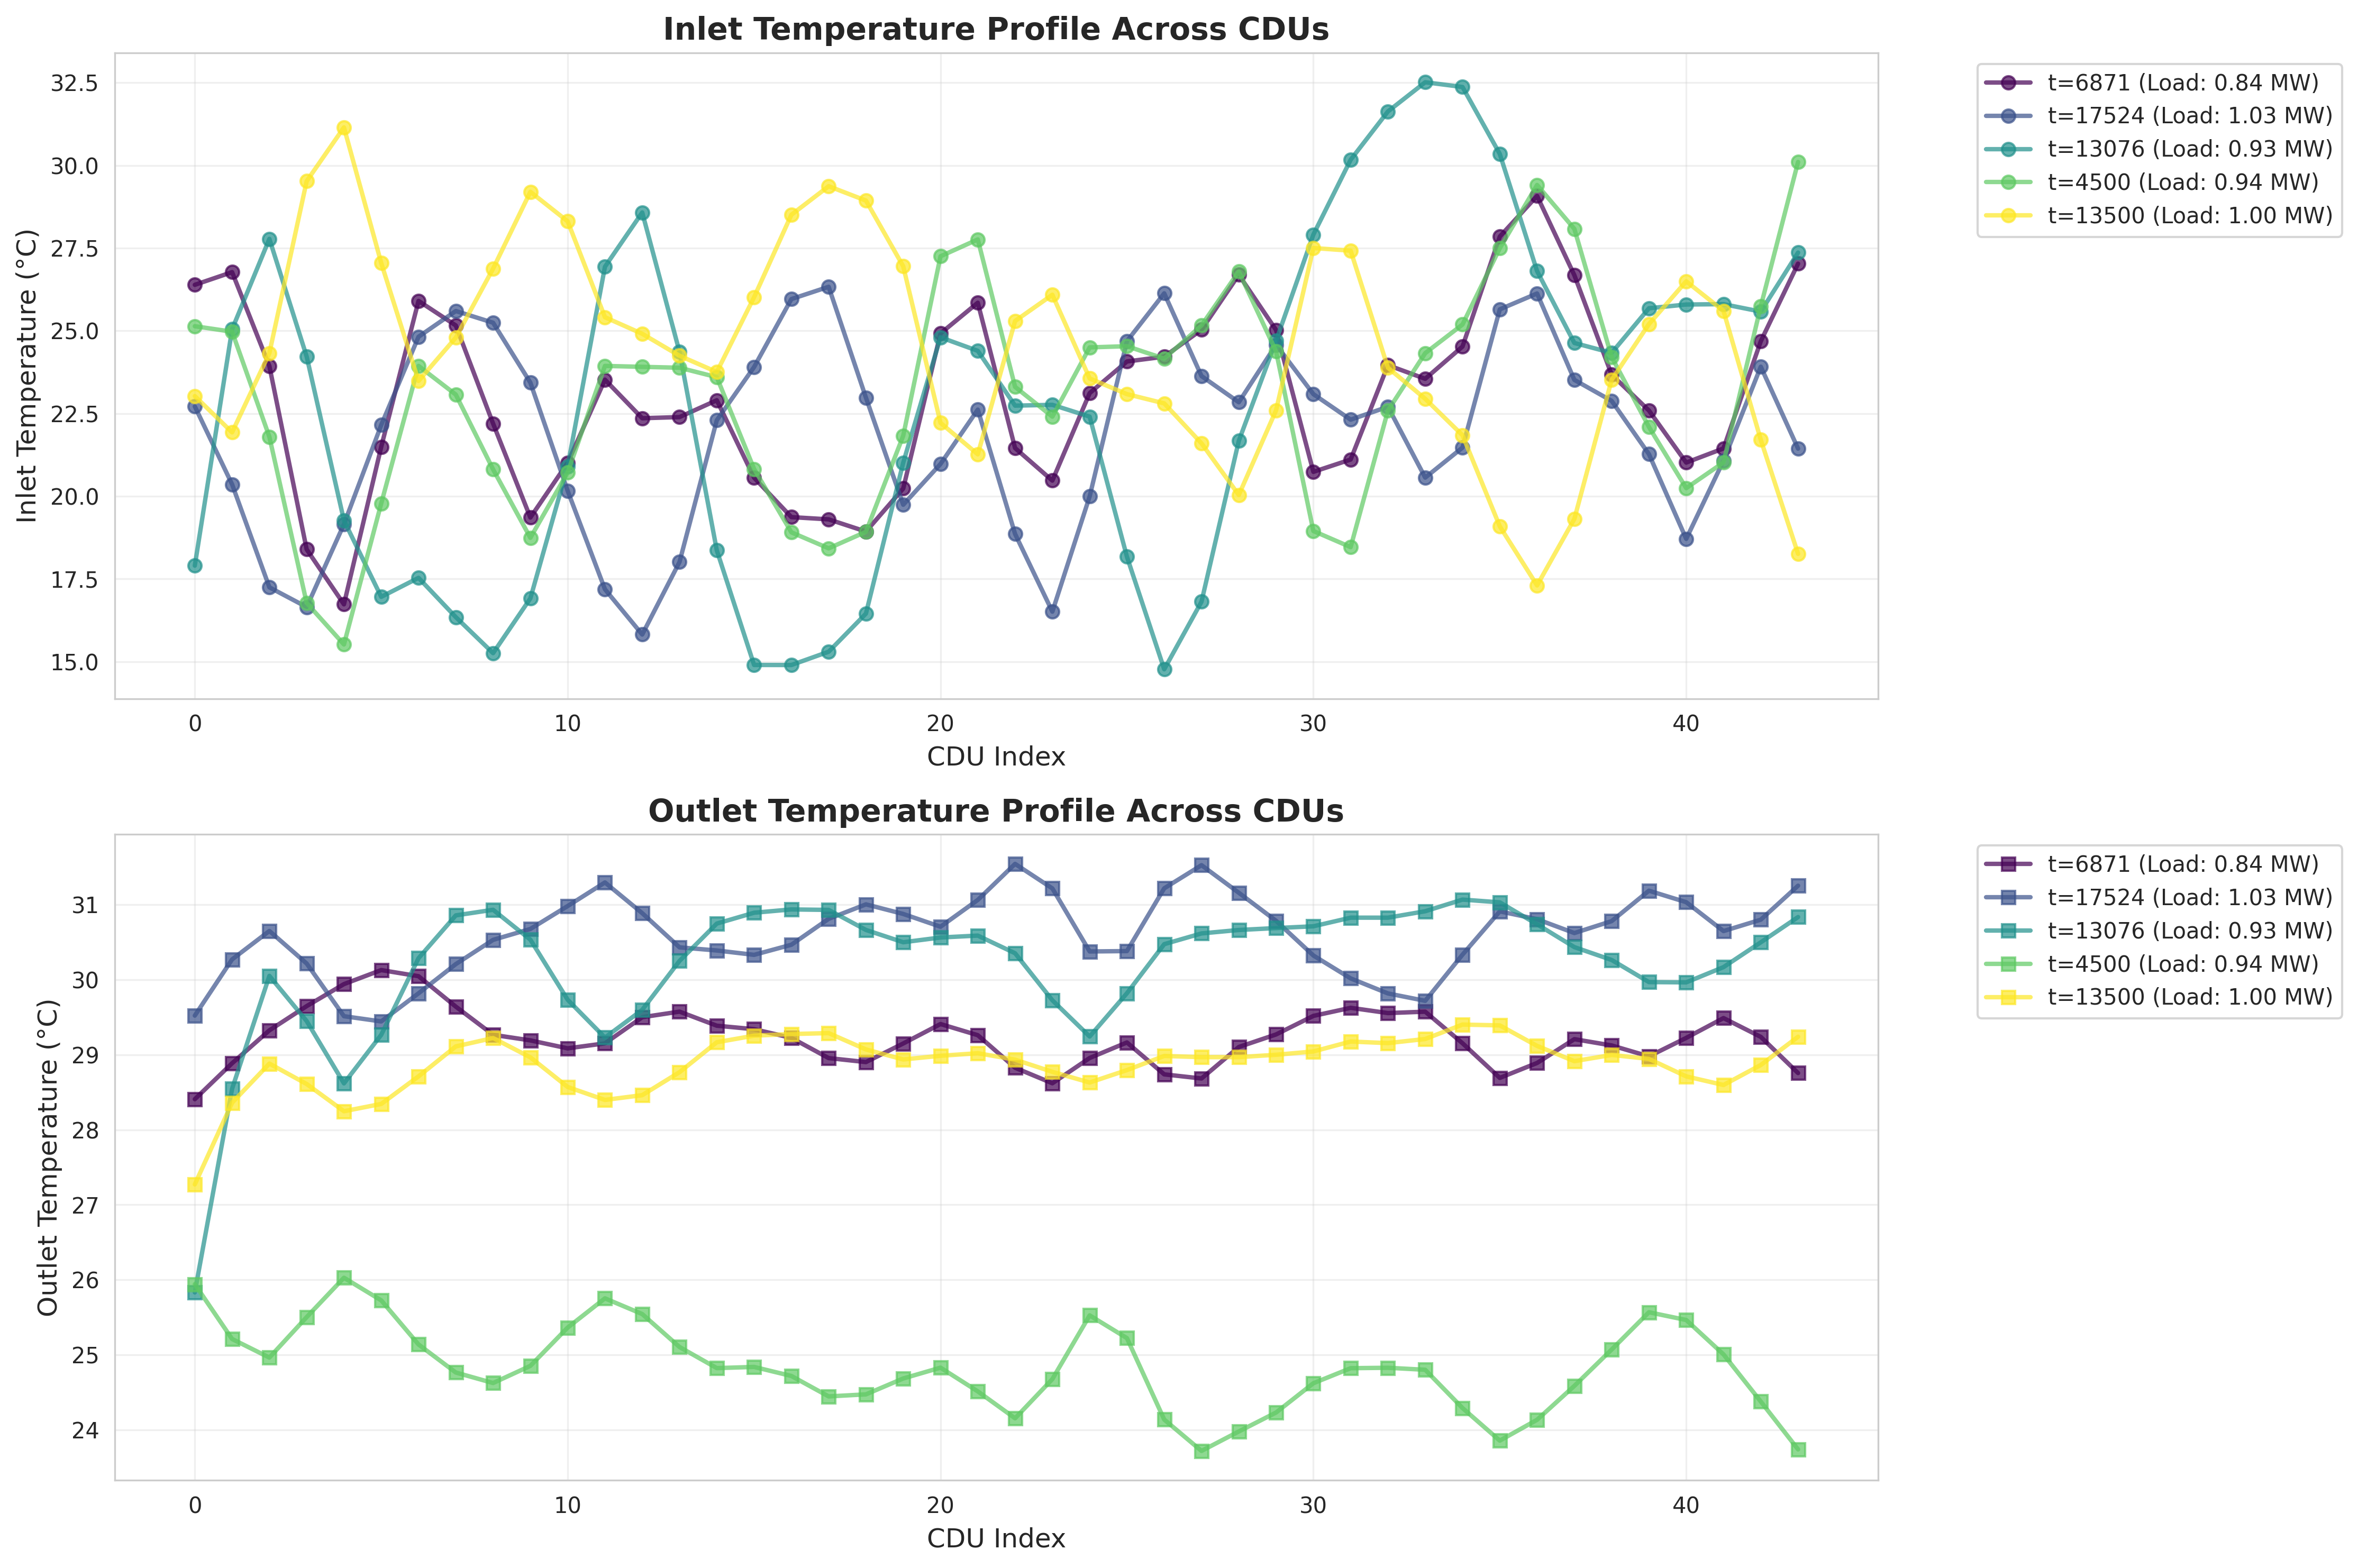

In [20]:
#  Temperature Gradient Analysis - Temperature Profiles
print("\n[1/5] Generating temperature profiles...")
temp_analyzer.plot_temperature_profile()

# Display the result
display(Image(filename=f'{TEMPERATURE_GRADIENT_DIR}/temperature_profiles.png'))


[2/5] Generating gradient vector field...
Saved gradient vector field to ../results/lassen/data_analysis/spatial_correlation/temperature_gradient


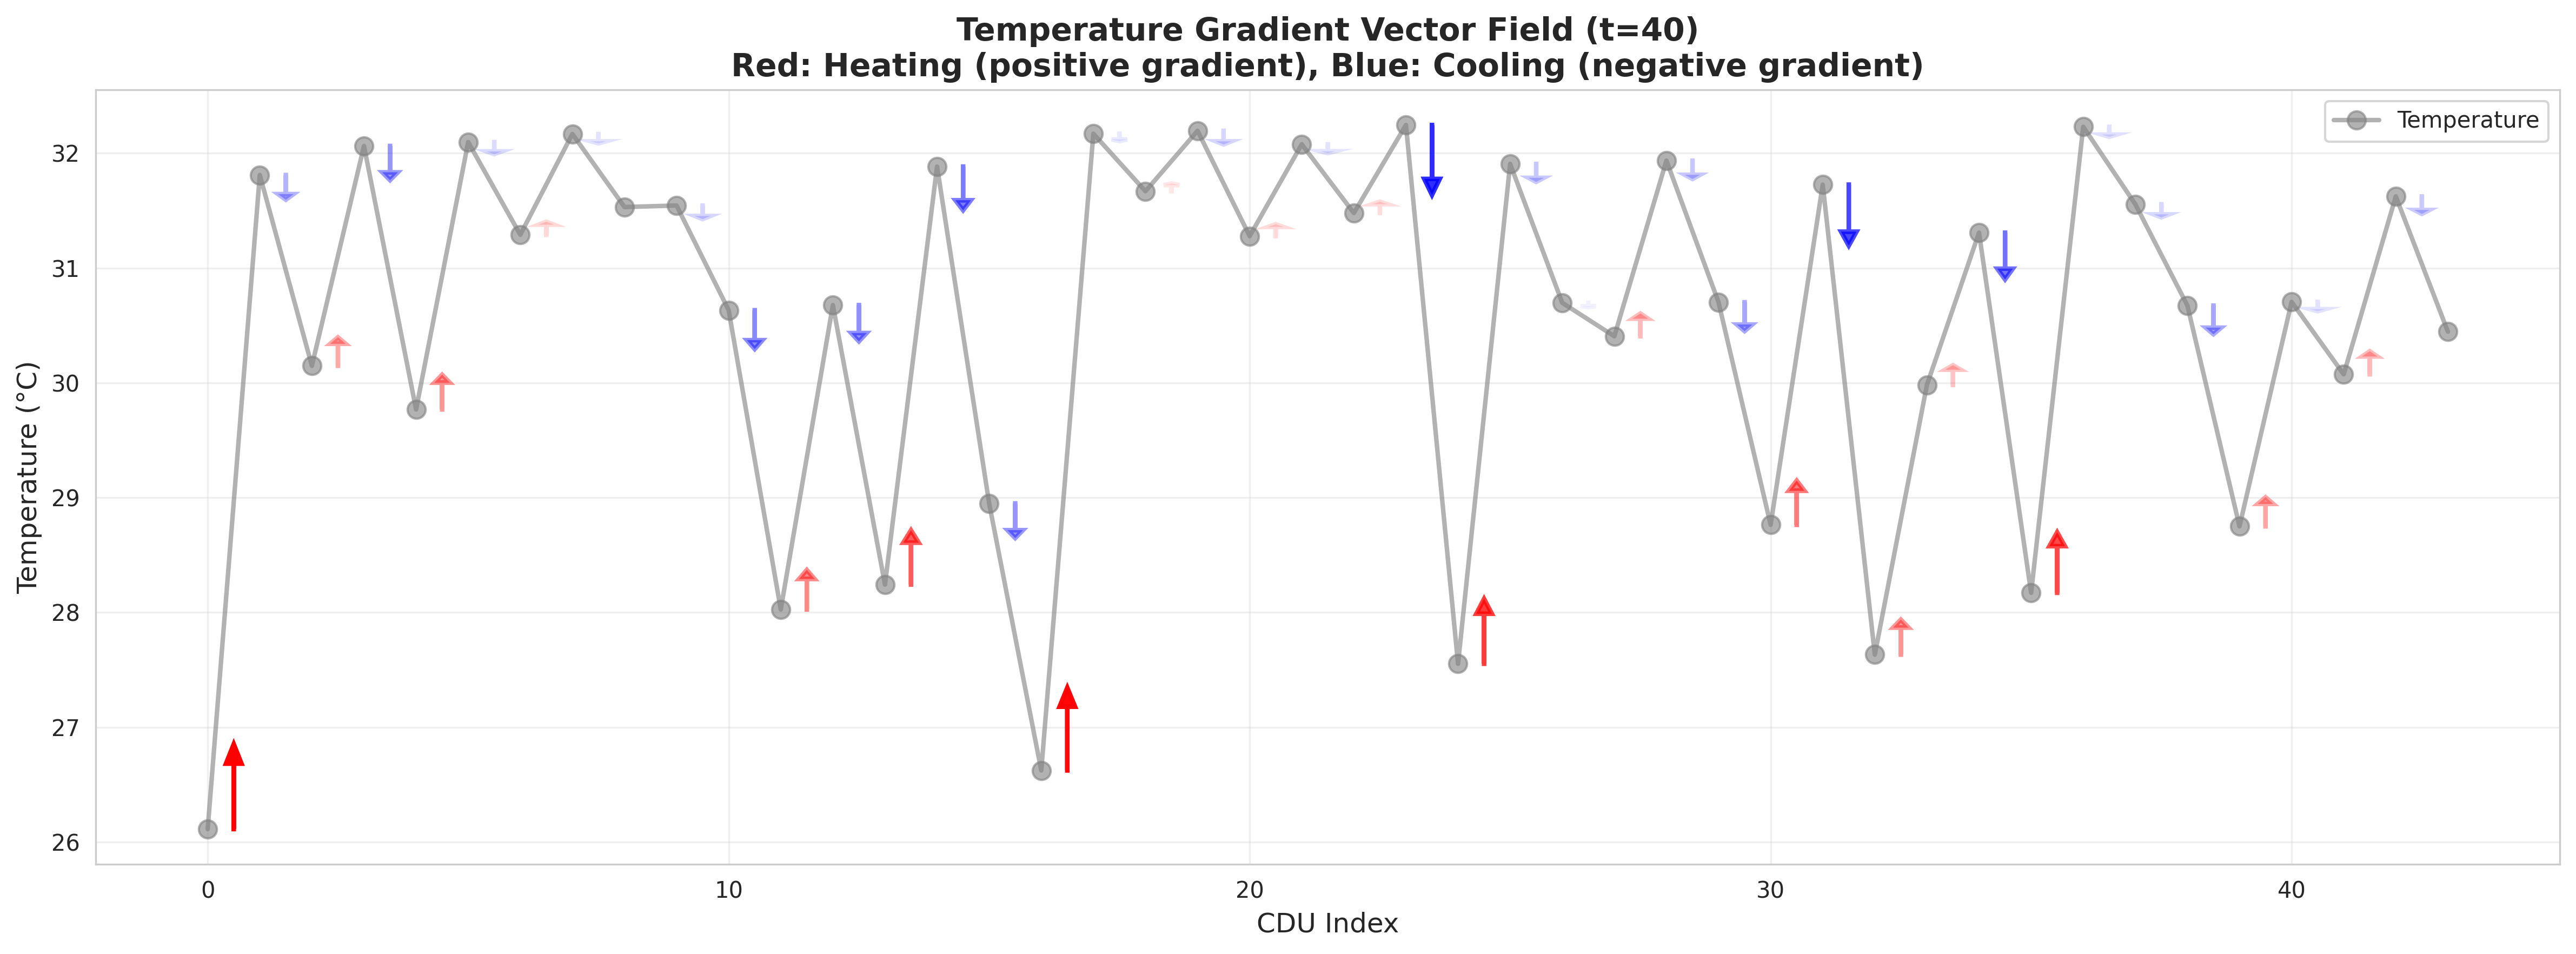

In [21]:
#  Temperature Gradient Analysis - Vector Field
print("\n[2/5] Generating gradient vector field...")
temp_analyzer.plot_gradient_vector_field()

# Display the result
vector_field_path = list(Path(TEMPERATURE_GRADIENT_DIR).glob('gradient_vector_field_t*.png'))[0]
display(Image(filename=str(vector_field_path)))


[3/5] Generating temperature difference heatmap...
Saved temperature difference heatmap to ../results/lassen/data_analysis/spatial_correlation/temperature_gradient


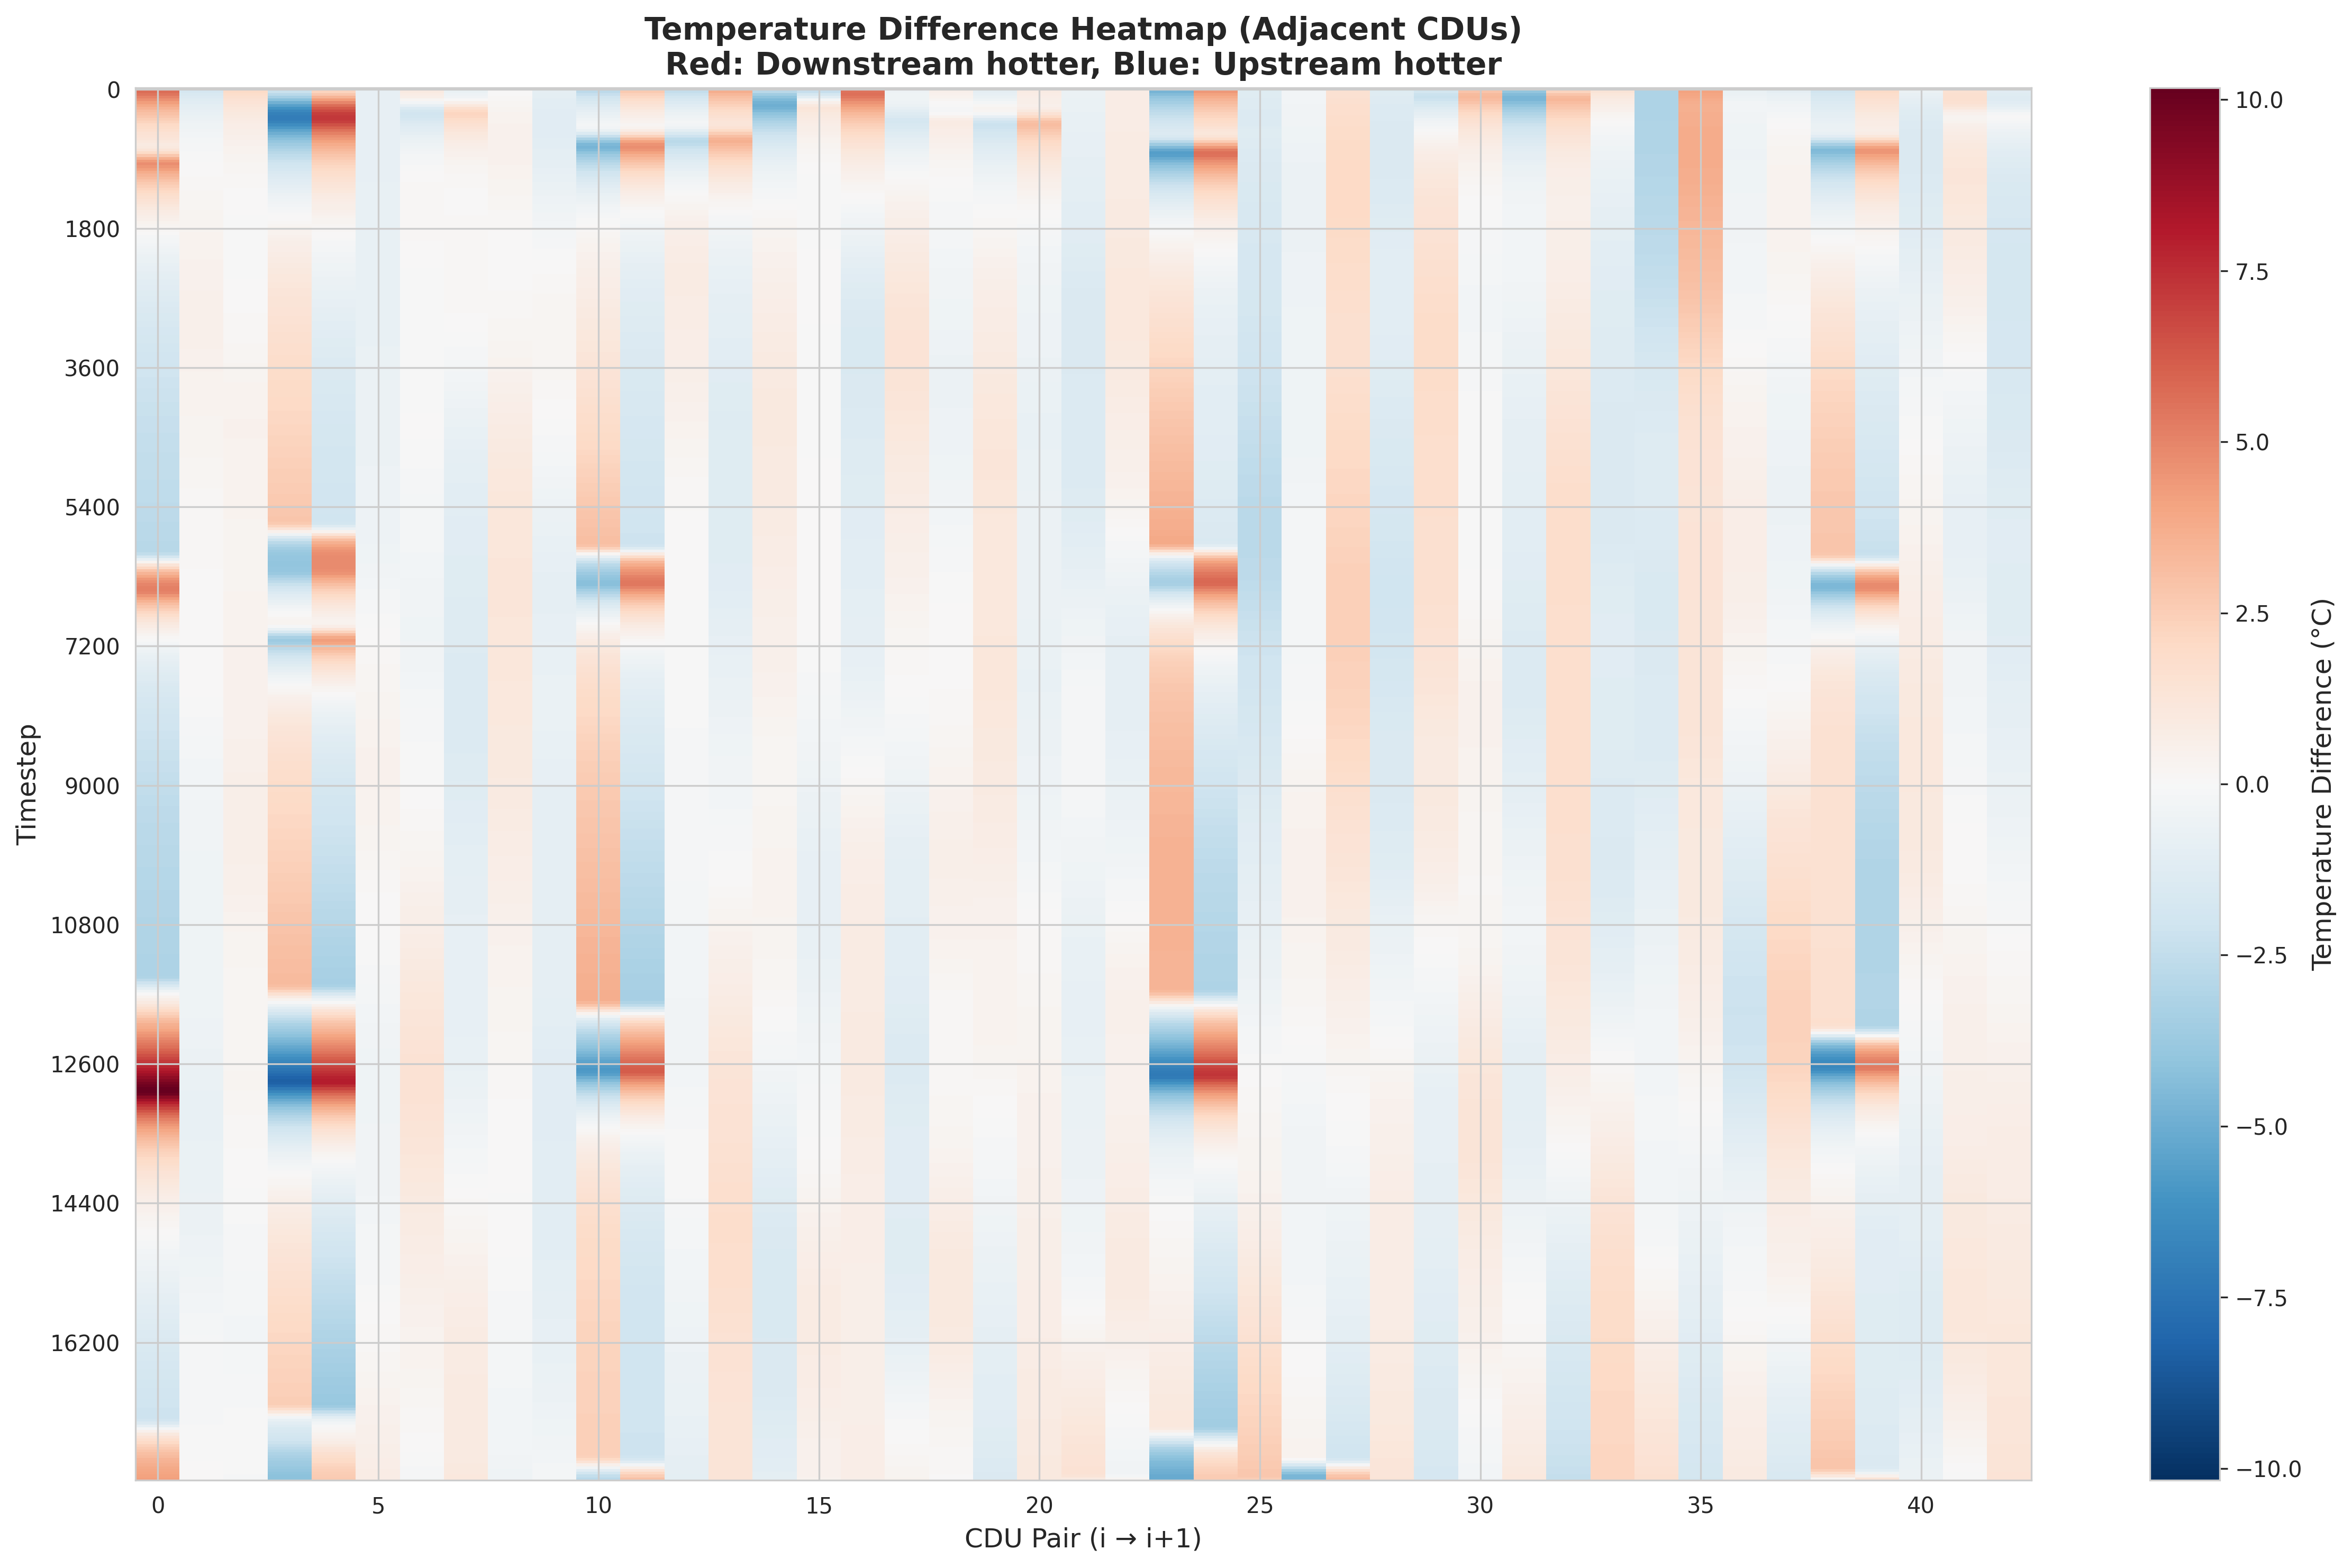

In [22]:
# Temperature Gradient Analysis - Heatmap
print("\n[3/5] Generating temperature difference heatmap...")
temp_analyzer.plot_temperature_difference_heatmap(max_timesteps=500)

# Display the result
display(Image(filename=f'{TEMPERATURE_GRADIENT_DIR}/temperature_difference_heatmap.png'))


[4/5] Generating gradient statistics...
Saved gradient statistics to ../results/lassen/data_analysis/spatial_correlation/temperature_gradient


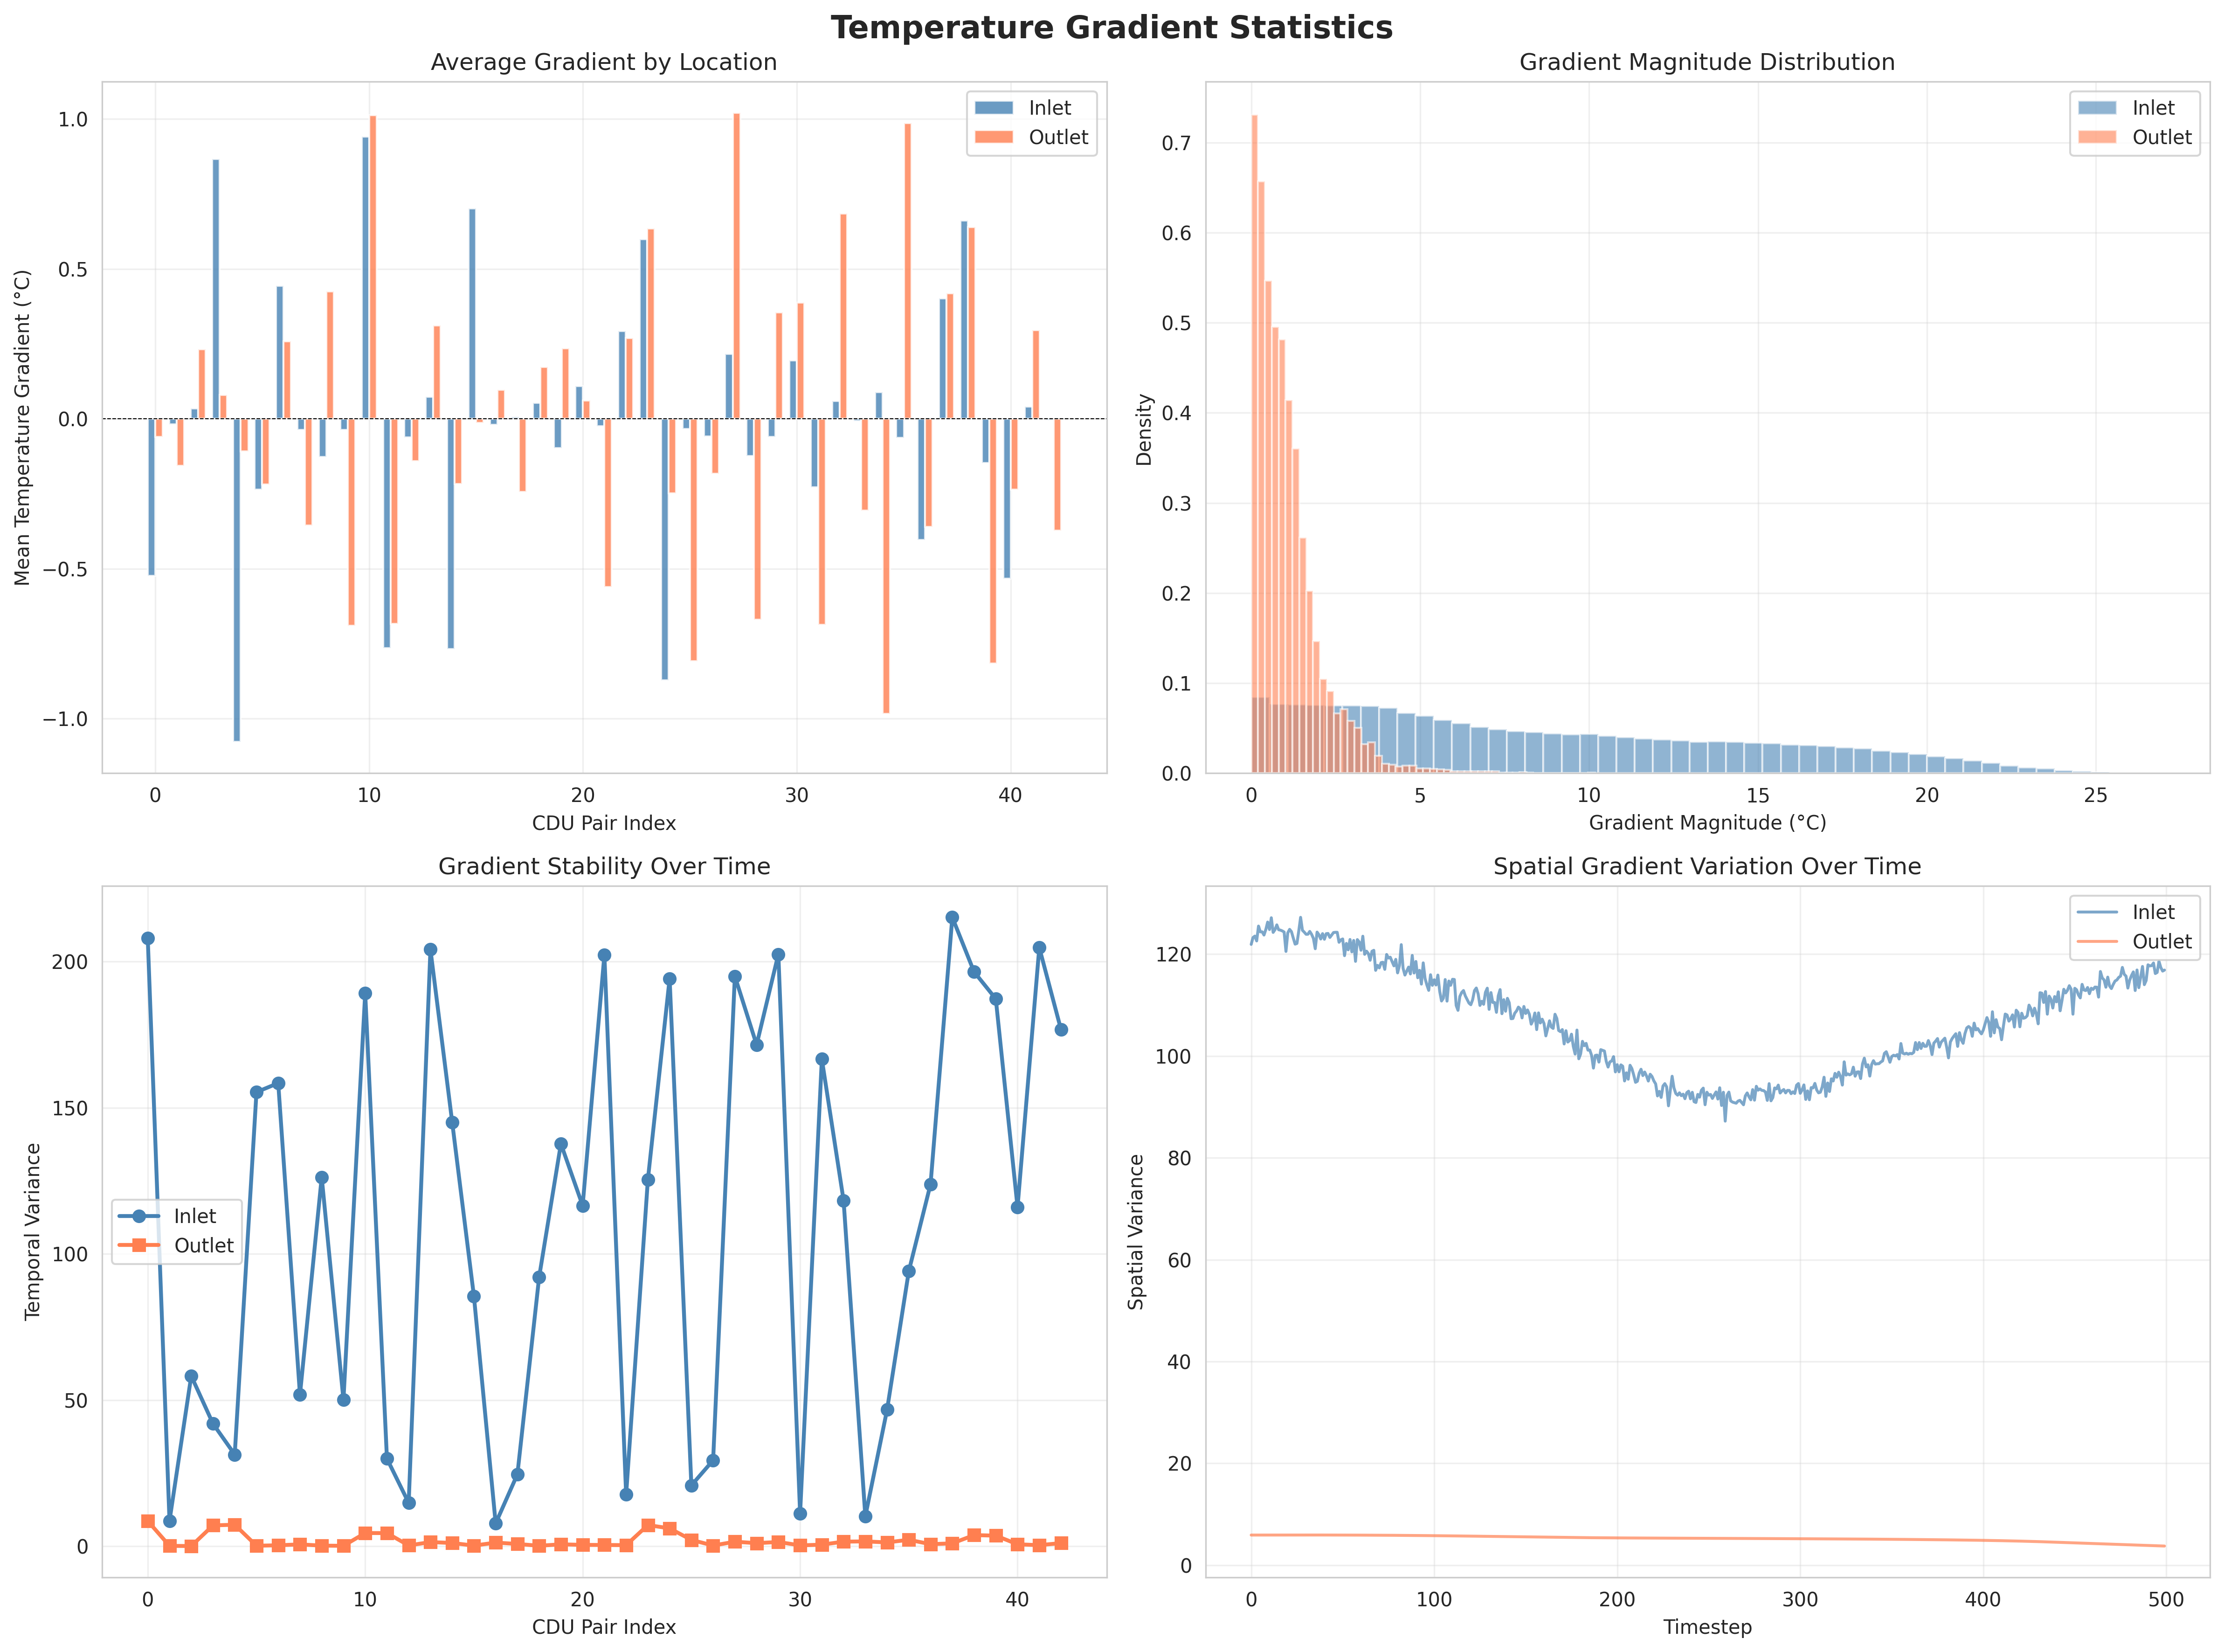

In [23]:
#  Temperature Gradient Analysis - Statistics
print("\n[4/5] Generating gradient statistics...")
temp_analyzer.plot_gradient_statistics()

# Display the result
display(Image(filename=f'{TEMPERATURE_GRADIENT_DIR}/gradient_statistics.png'))

In [24]:
# Temperature Gradient Analysis - Summary Report
print("\n[5/5] Generating summary report...")
summary = temp_analyzer.generate_summary_report()

# Display as formatted markdown
display(Markdown(f"```\n{summary}\n```"))


[5/5] Generating summary report...

Analyzing gradient persistence (parallelized)...

Analyzing propagation asymmetry...
Positive gradients: 375474 (mean: 1.080°C)
Negative gradients: 398526 (mean: -1.042°C)

Identifying hot zones (parallelized)...
Identified 44 potential hot zones

Top 5 hot zones by temperature elevation:
  CDU 28: ΔT = 1.49°C
  CDU 33: ΔT = 1.29°C
  CDU 26: ΔT = 0.95°C
  CDU 36: ΔT = 0.93°C
  CDU 1: ΔT = 0.87°C
TEMPERATURE GRADIENT ANALYSIS SUMMARY

### GRADIENT MAGNITUDE ###
Inlet  - Mean: 8.522°C, Max: 27.027°C, Std: 6.191°C
Outlet - Mean: 1.061°C, Max: 10.176°C, Std: 0.998°C

### GRADIENT PERSISTENCE ###
Inlet  - Mean persistence: 0.995
Outlet - Mean persistence: 1.000

### ASYMMETRY ###
Positive gradients: 375474 (mean: 1.080°C)
Negative gradients: 398526 (mean: -1.042°C)
Asymmetry ratio: 0.94

### HOT ZONES ###
Total hot zones identified: 44

Top 5 hot zones:
  CDU 28: Temperature elevation = 1.49°C, High-load events = 1800
  CDU 33: Temperature elevation = 1.

```
================================================================================
TEMPERATURE GRADIENT ANALYSIS SUMMARY
================================================================================

### GRADIENT MAGNITUDE ###
Inlet  - Mean: 8.522°C, Max: 27.027°C, Std: 6.191°C
Outlet - Mean: 1.061°C, Max: 10.176°C, Std: 0.998°C

### GRADIENT PERSISTENCE ###
Inlet  - Mean persistence: 0.995
Outlet - Mean persistence: 1.000

### ASYMMETRY ###
Positive gradients: 375474 (mean: 1.080°C)
Negative gradients: 398526 (mean: -1.042°C)
Asymmetry ratio: 0.94

### HOT ZONES ###
Total hot zones identified: 44

Top 5 hot zones:
  CDU 28: Temperature elevation = 1.49°C, High-load events = 1800
  CDU 33: Temperature elevation = 1.29°C, High-load events = 1800
  CDU 26: Temperature elevation = 0.95°C, High-load events = 1800
  CDU 36: Temperature elevation = 0.93°C, High-load events = 1800
  CDU 1: Temperature elevation = 0.87°C, High-load events = 1800

================================================================================
```

## Load Propagation Analysis

In [25]:
# Load Propagation Analysis - Initialize and Load
print("="*80)
print("LOAD PROPAGATION ANALYSIS")
print("="*80)

load_analyzer = LoadPropagationAnalyzer(
    data_path=DATA_PATH,
    output_dir=LOAD_PROPAGATION_DIR,
    n_workers=N_WORKERS
)

# Load data
load_analyzer.load_data(sample_size=SAMPLE_SIZE)

LOAD PROPAGATION ANALYSIS
Loading data from ../data/lassen/systematic/spatial_analysis_output_5hr.parquet...
Using 49 workers for parallel processing
Found 44 CDUs
Loaded 18000 timesteps


In [26]:
# Load Propagation Analysis - Identify Spikes
print("\nIdentifying load spikes...")
spikes = load_analyzer.identify_load_spikes(threshold_percentile=95)

# Display spike statistics
spike_counts = {cdu: len(spike_list) for cdu, spike_list in spikes.items()}
print(f"\nTotal spikes detected: {sum(spike_counts.values())}")
print(f"CDUs with most spikes:")
sorted_spikes = sorted(spike_counts.items(), key=lambda x: x[1], reverse=True)[:5]
for cdu_idx, count in sorted_spikes:
    print(f"  CDU {cdu_idx}: {count} spikes")


Identifying load spikes...

Identifying load spikes...
CDU 0: 900 spikes detected
CDU 1: 900 spikes detected
CDU 2: 900 spikes detected
CDU 3: 900 spikes detected
CDU 4: 900 spikes detected
CDU 5: 900 spikes detected
CDU 6: 900 spikes detected
CDU 7: 900 spikes detected
CDU 8: 900 spikes detected
CDU 9: 900 spikes detected
CDU 10: 900 spikes detected
CDU 11: 900 spikes detected
CDU 12: 900 spikes detected
CDU 13: 900 spikes detected
CDU 14: 900 spikes detected
CDU 15: 900 spikes detected
CDU 16: 900 spikes detected
CDU 17: 900 spikes detected
CDU 18: 900 spikes detected
CDU 19: 900 spikes detected
CDU 20: 900 spikes detected
CDU 21: 900 spikes detected
CDU 22: 900 spikes detected
CDU 23: 900 spikes detected
CDU 24: 900 spikes detected
CDU 25: 900 spikes detected
CDU 26: 900 spikes detected
CDU 27: 900 spikes detected
CDU 28: 900 spikes detected
CDU 29: 900 spikes detected
CDU 30: 900 spikes detected
CDU 31: 900 spikes detected
CDU 32: 900 spikes detected
CDU 33: 900 spikes detected
CD


Generating propagation maps for selected CDUs...
  Analyzing CDU 0 at spike timestep 2
Saved propagation map to ../results/lassen/data_analysis/spatial_correlation/load_propagation
  Analyzing CDU 22 at spike timestep 45
Saved propagation map to ../results/lassen/data_analysis/spatial_correlation/load_propagation
  Analyzing CDU 43 at spike timestep 66
Saved propagation map to ../results/lassen/data_analysis/spatial_correlation/load_propagation

Propagation map for CDU 0:


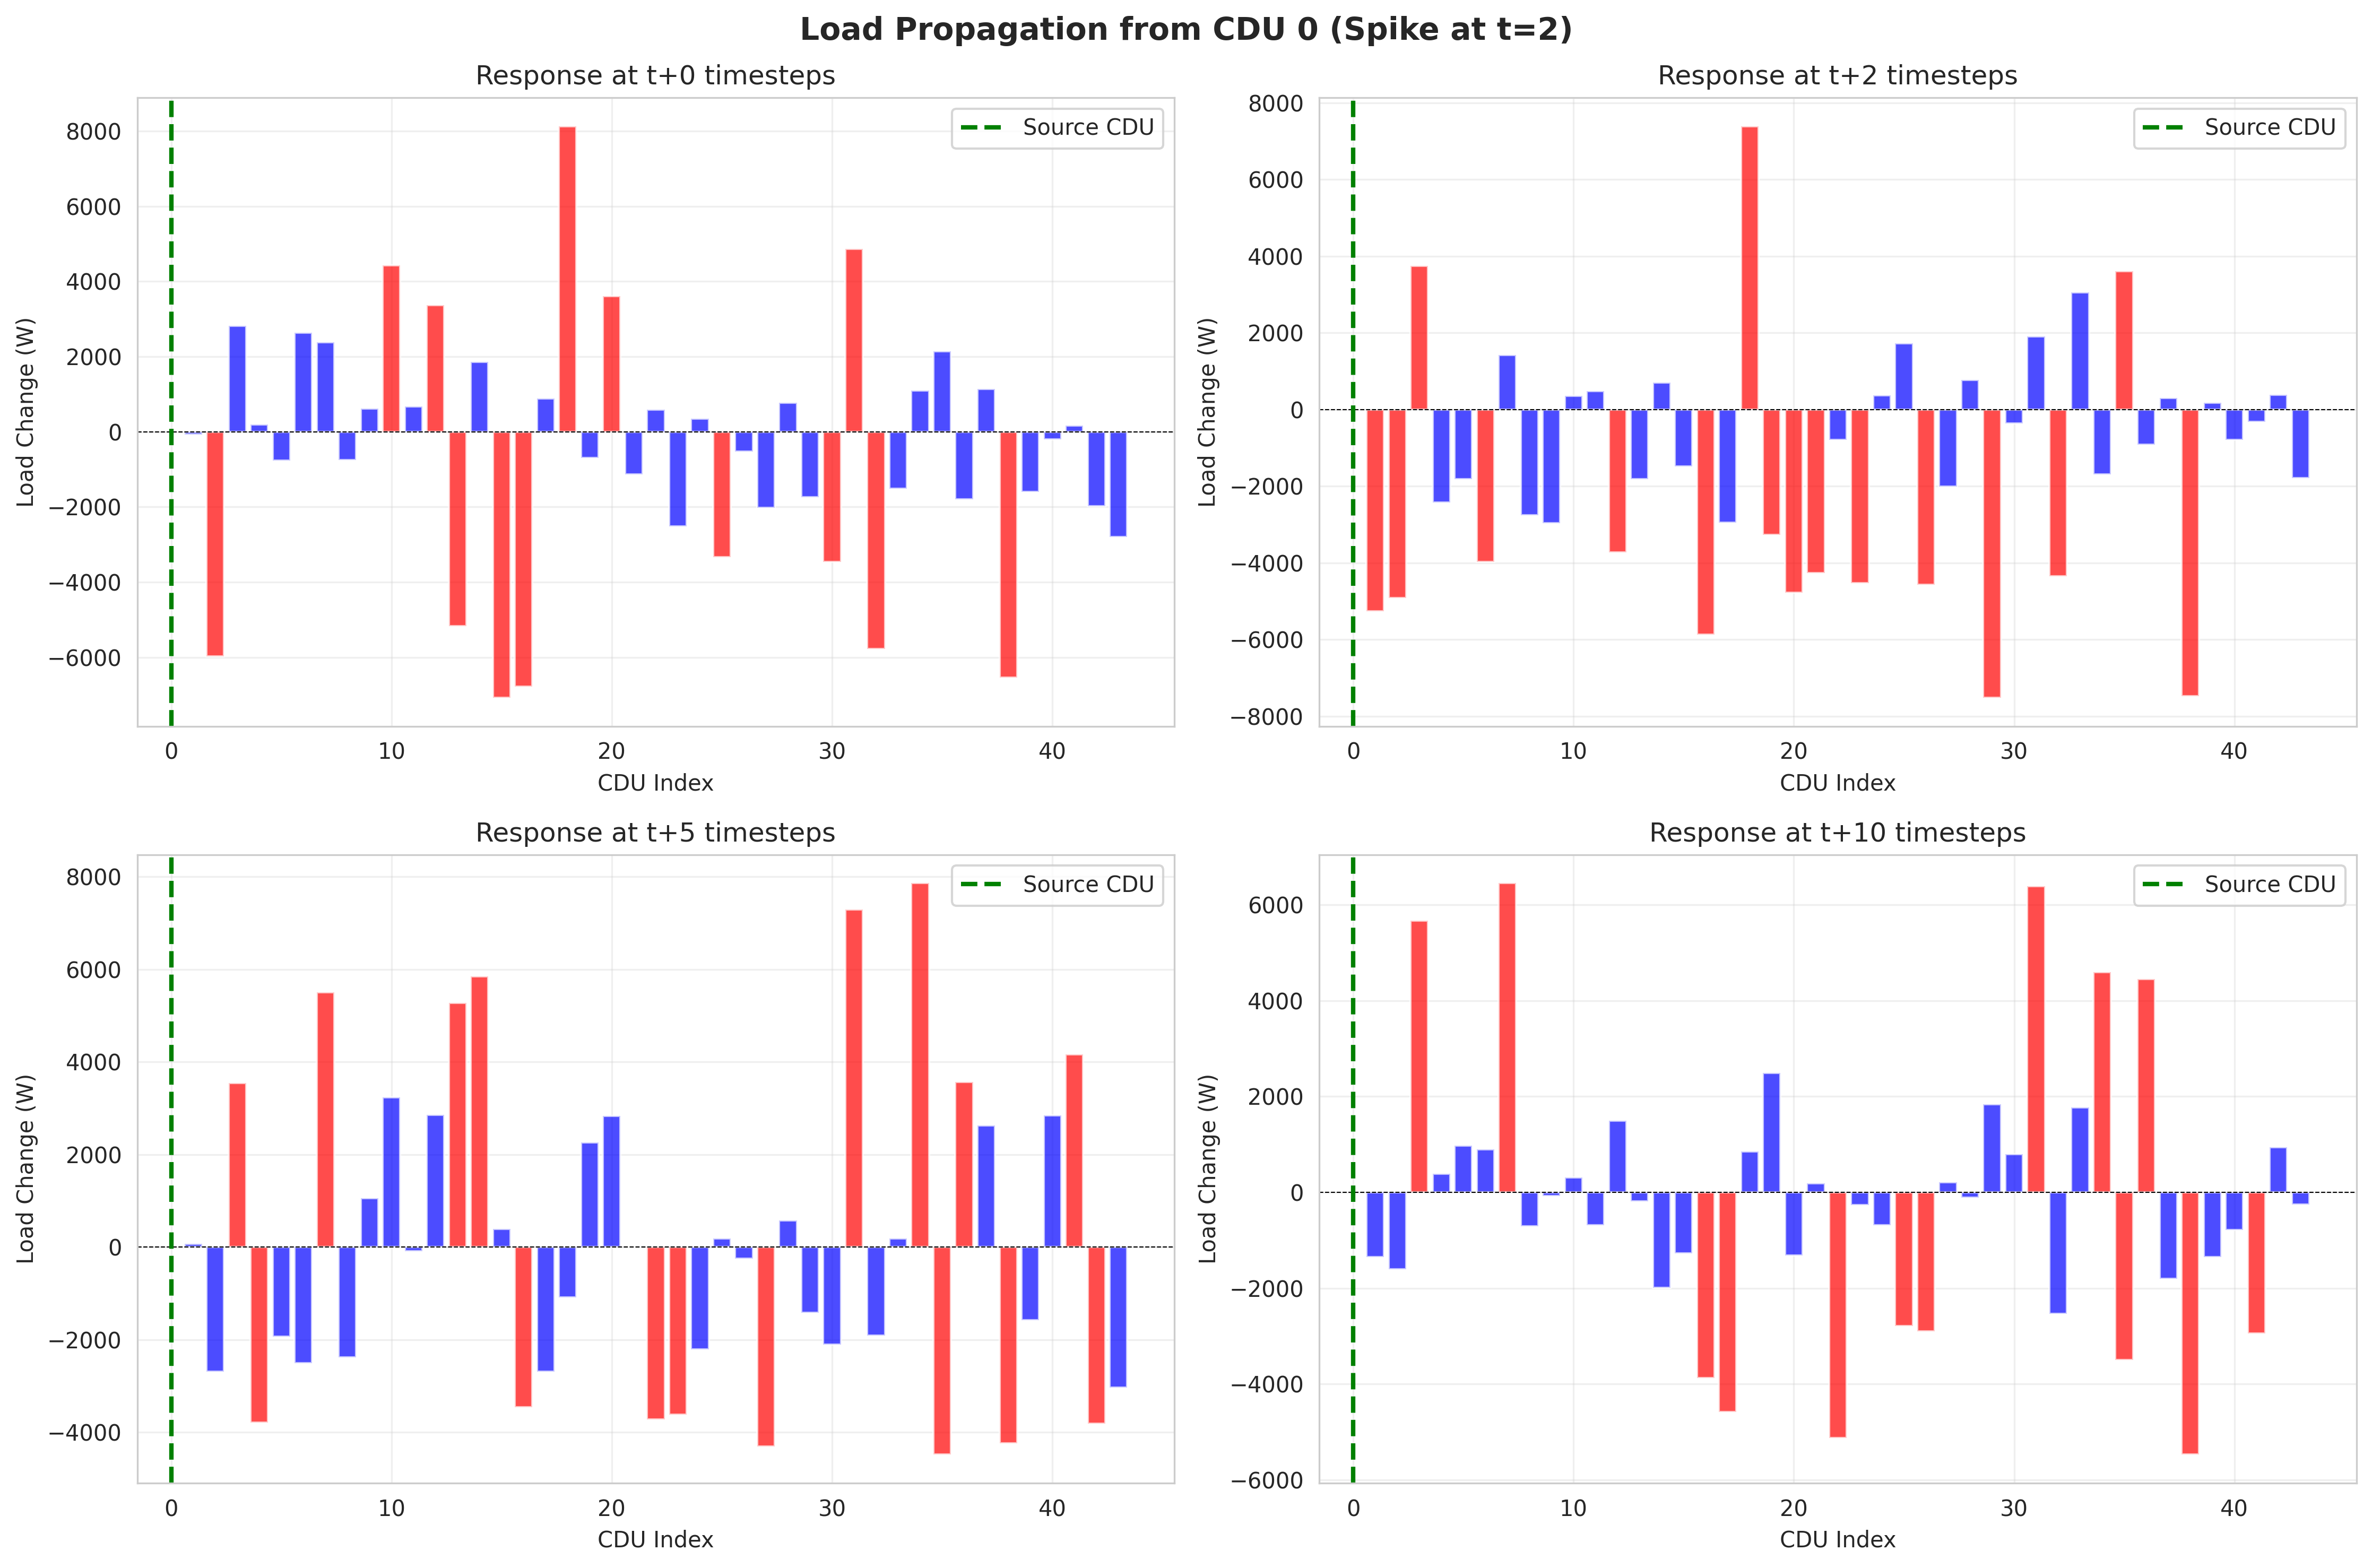


Propagation map for CDU 22:


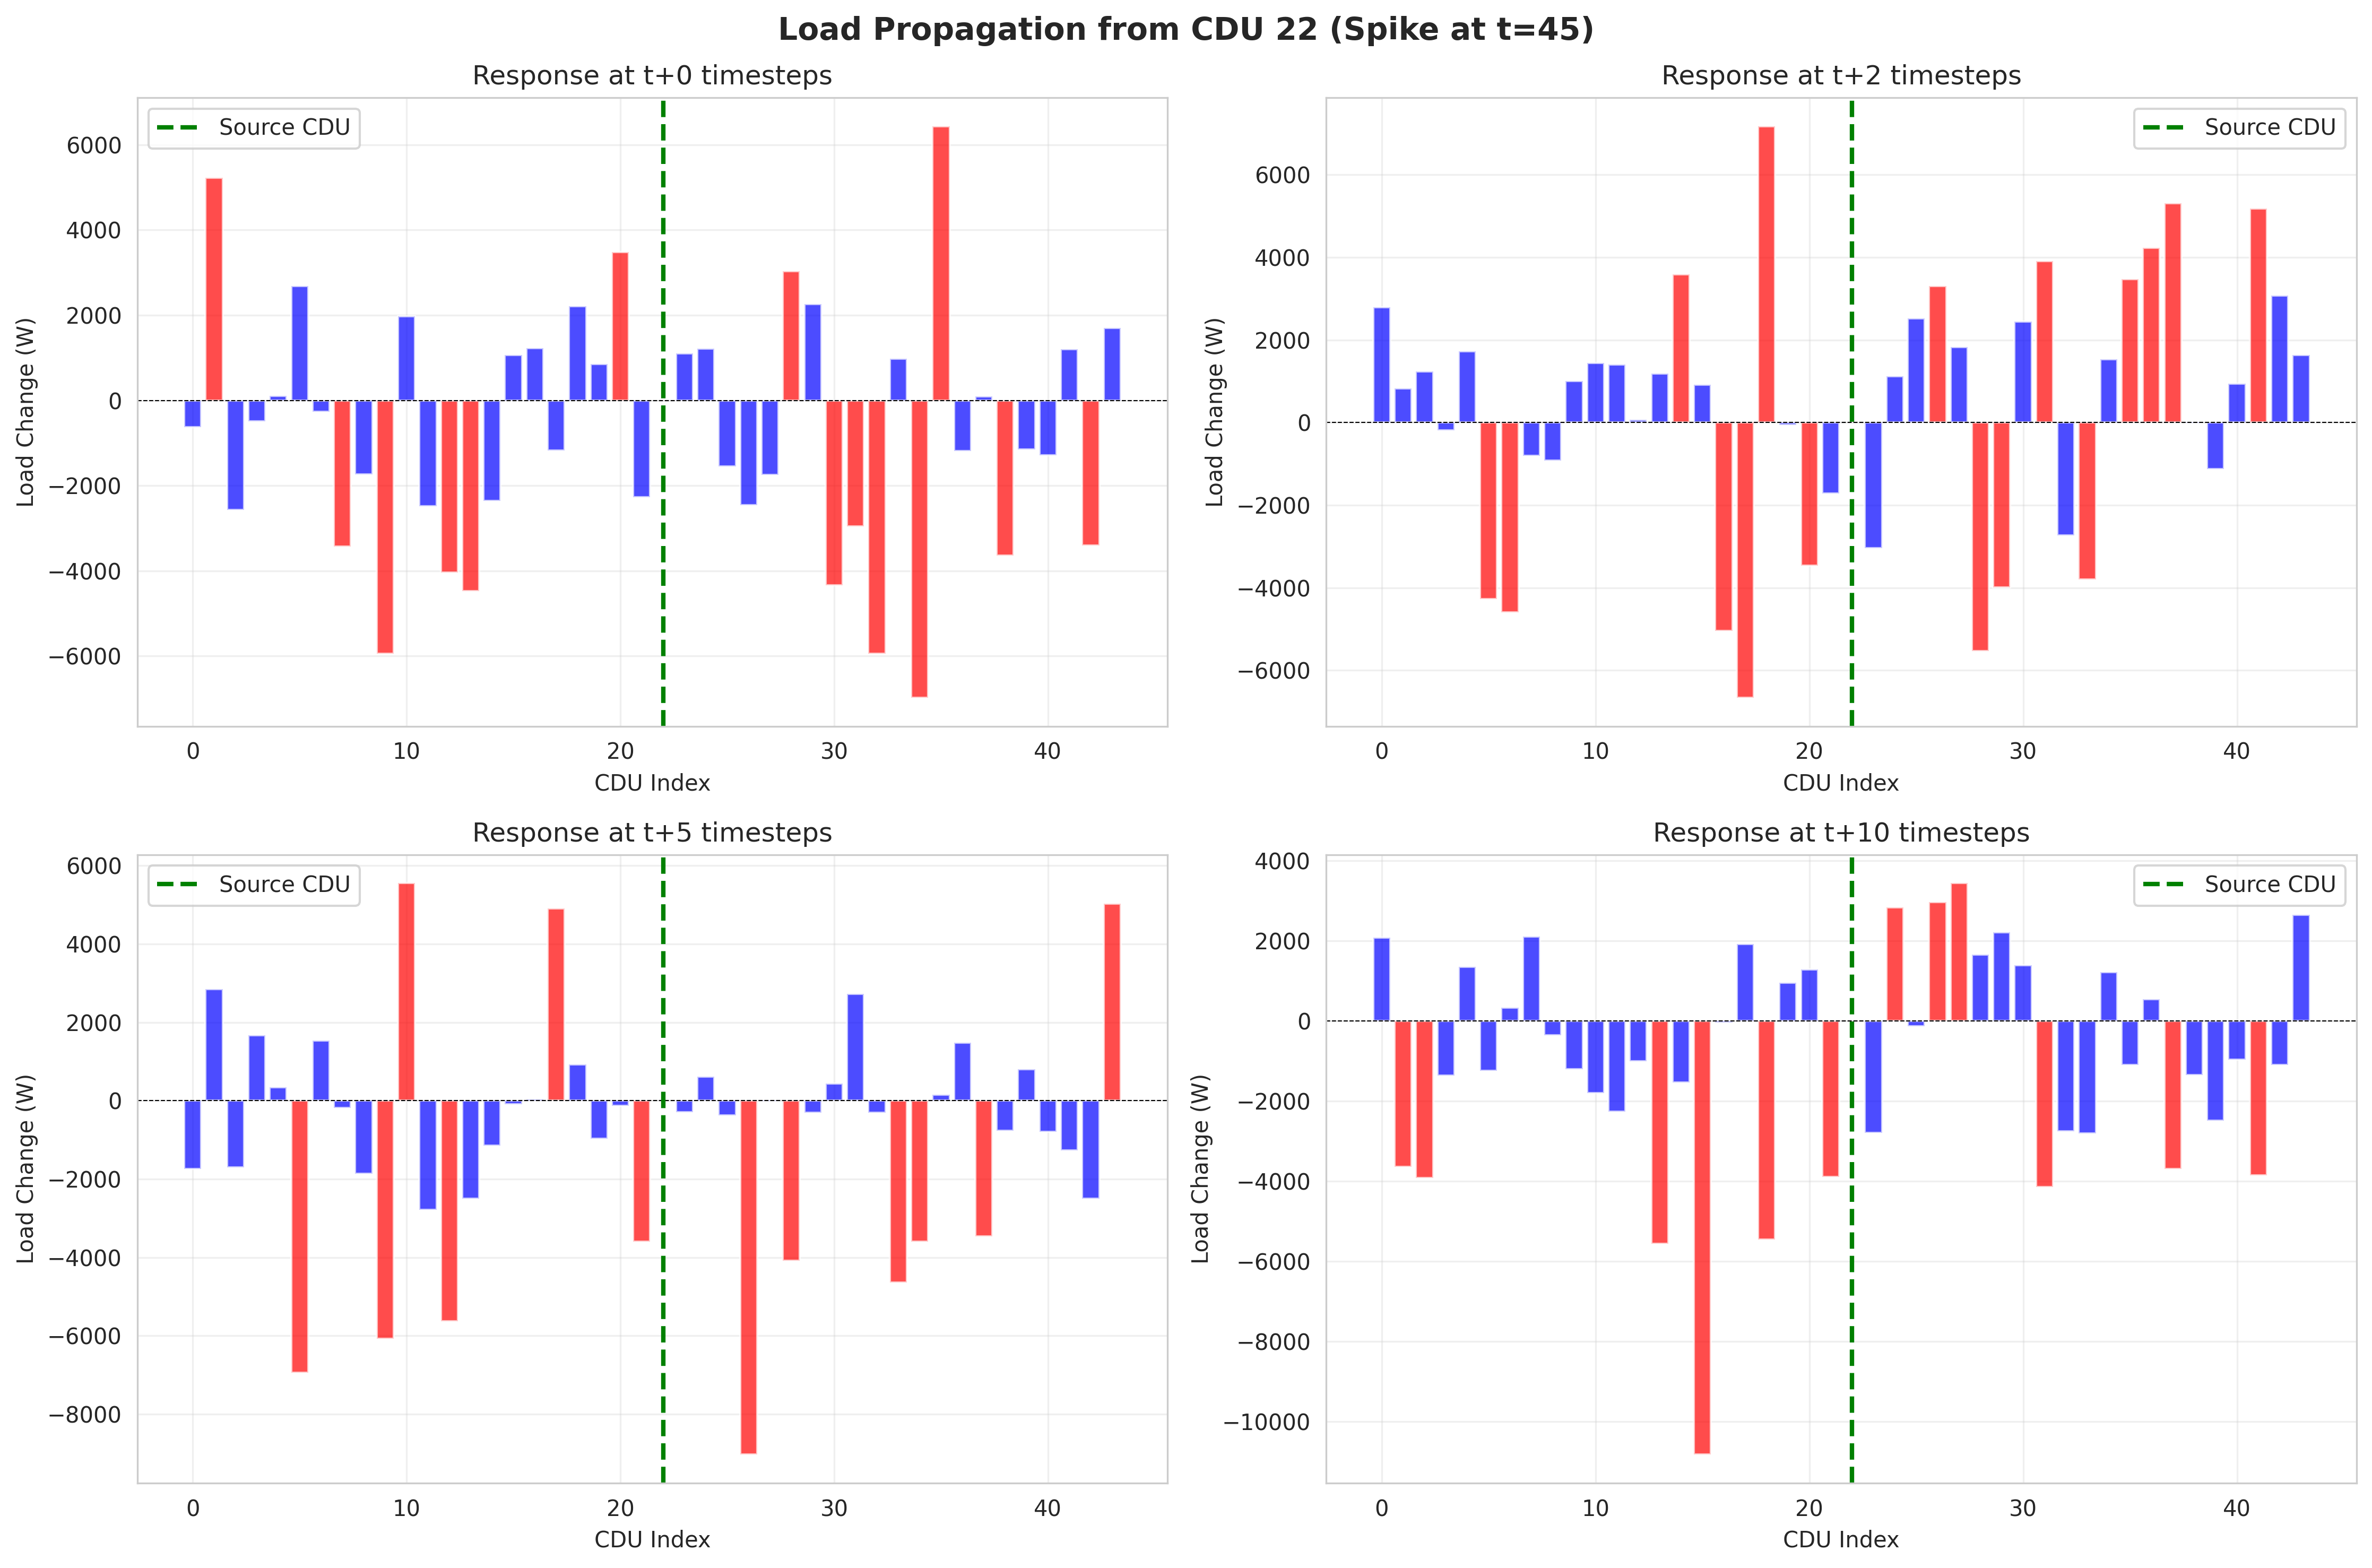


Propagation map for CDU 43:


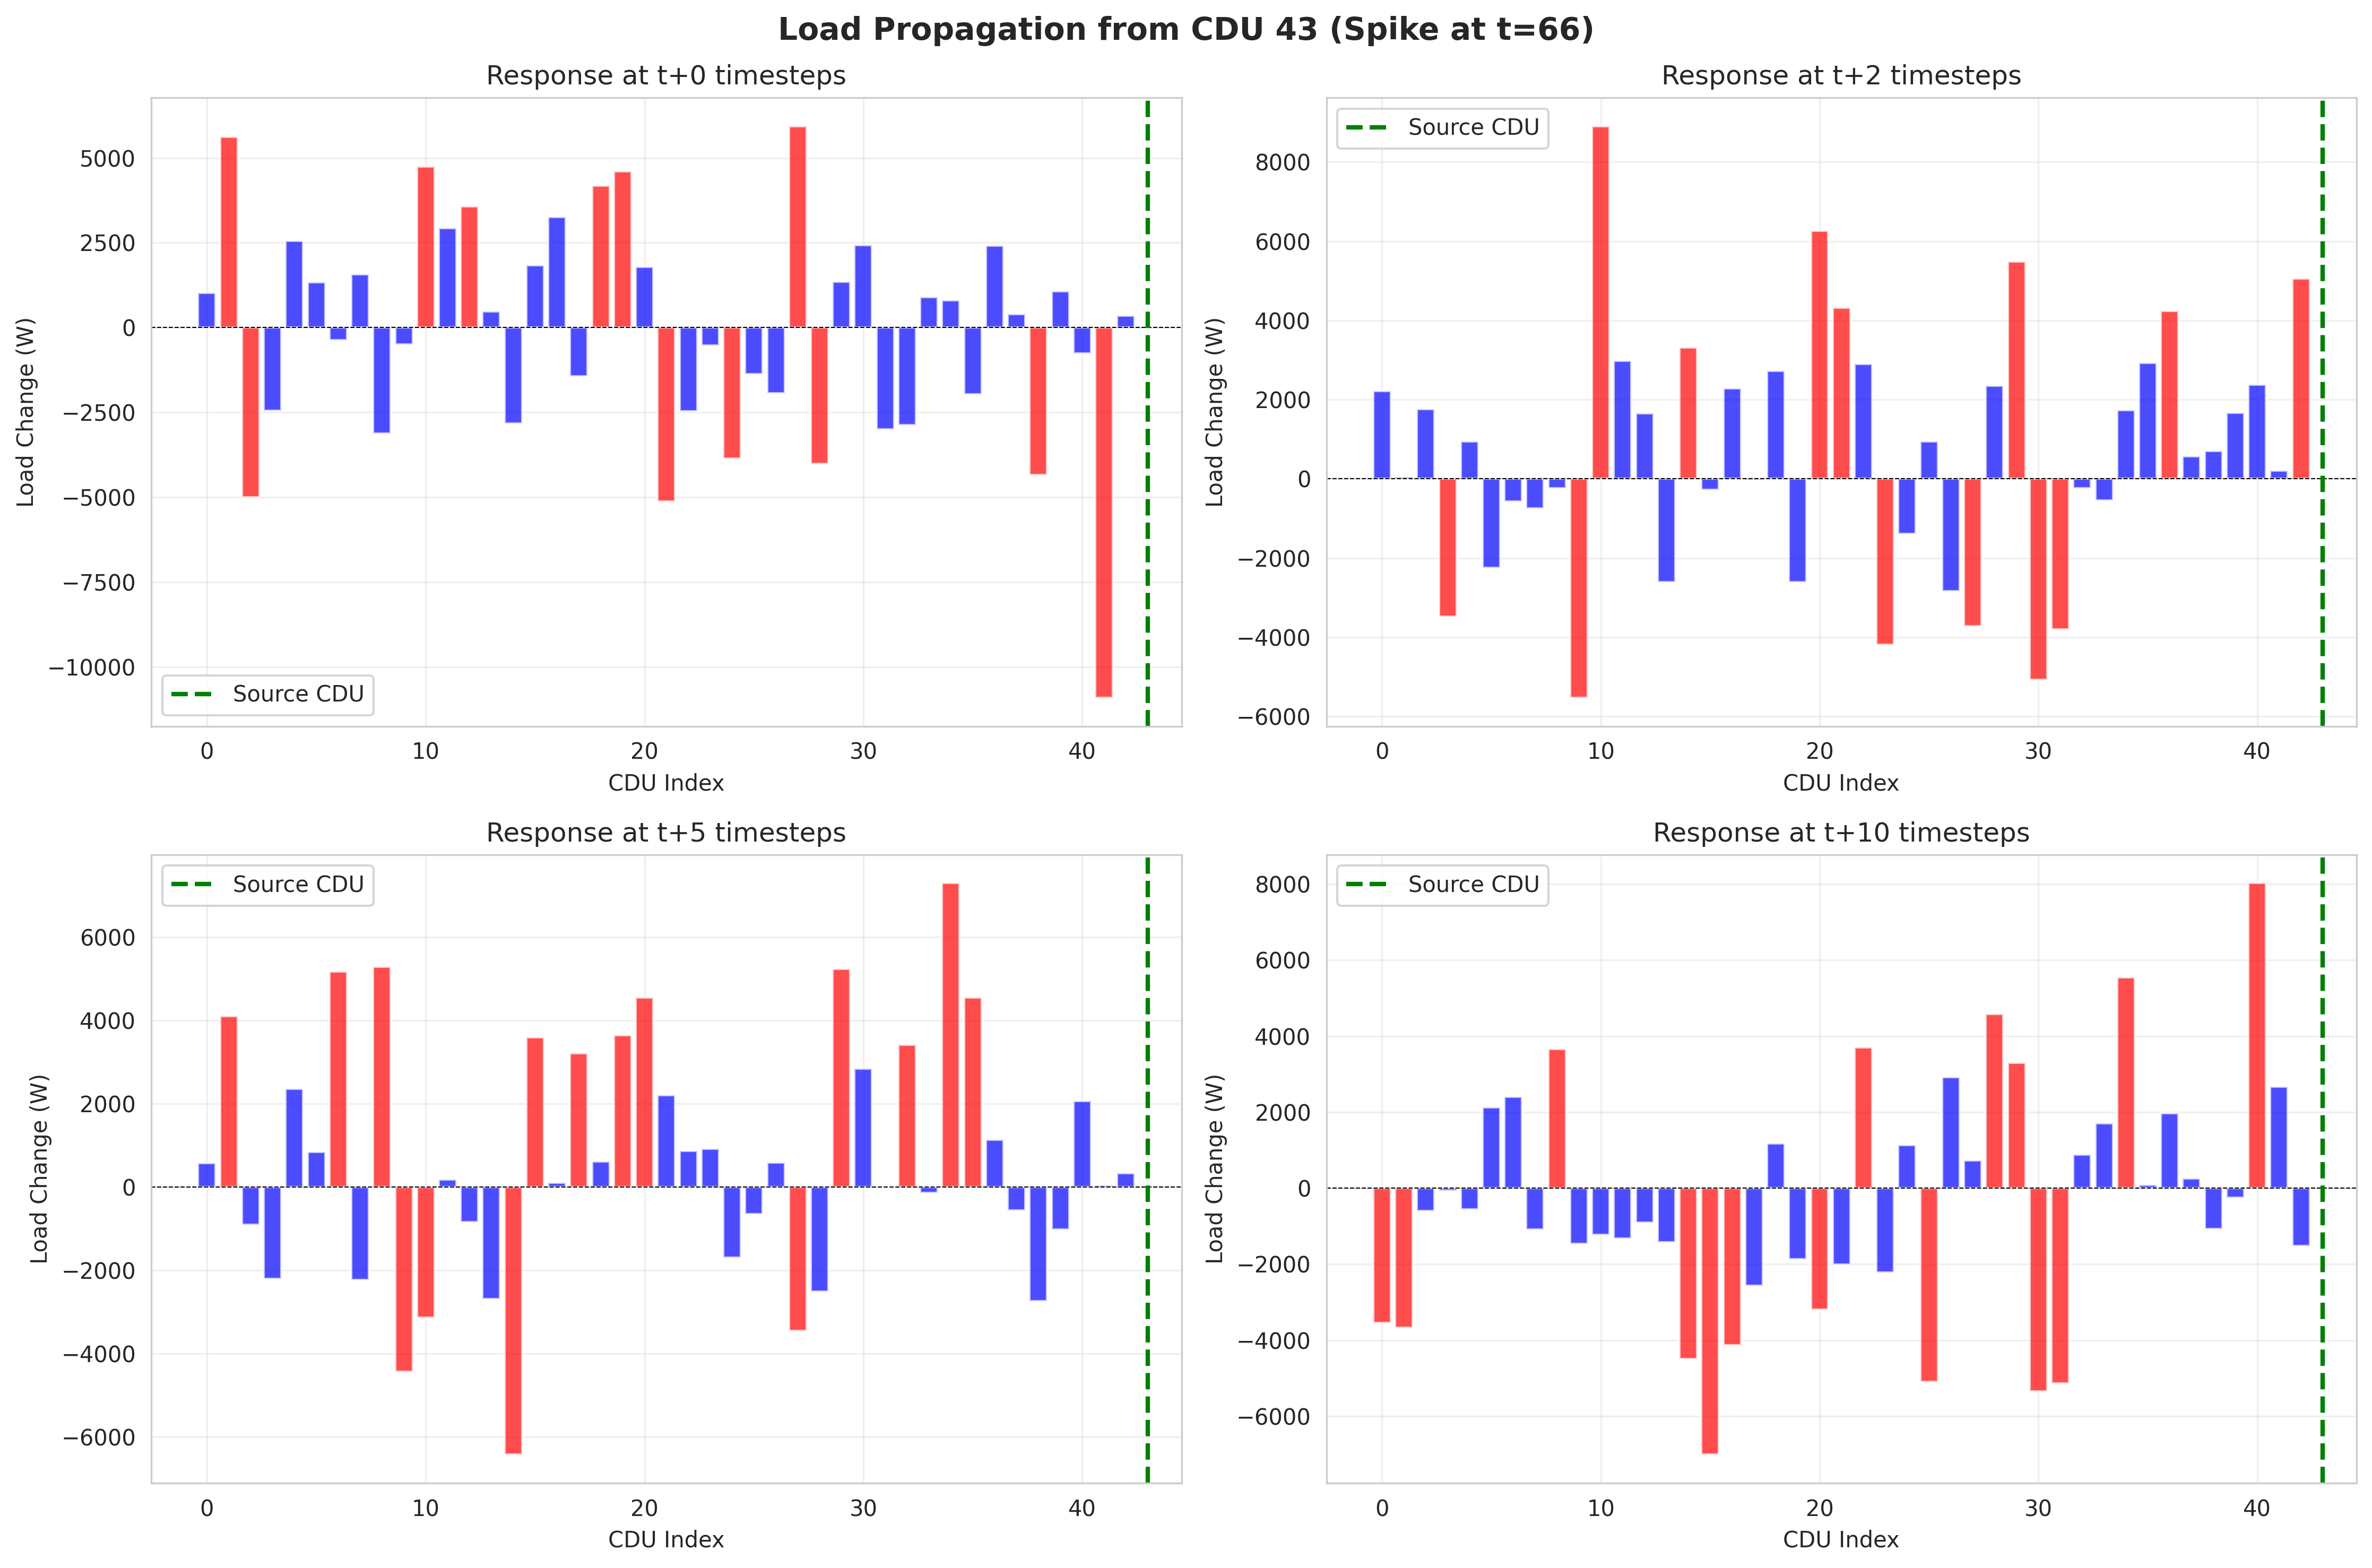

In [27]:
# Load Propagation Analysis - Propagation Maps
print("\nGenerating propagation maps for selected CDUs...")

# Select CDUs for detailed analysis
analysis_cdus = [0, load_analyzer.n_cdus//2, load_analyzer.n_cdus-1]

for cdu_idx in analysis_cdus:
    if spikes[cdu_idx]:
        spike_idx = spikes[cdu_idx][0]  # Use first spike
        print(f"  Analyzing CDU {cdu_idx} at spike timestep {spike_idx}")
        load_analyzer.create_propagation_map(cdu_idx, spike_idx, window=20)

# Display propagation maps
for cdu_idx in analysis_cdus:
    if spikes[cdu_idx]:
        spike_idx = spikes[cdu_idx][0]
        map_path = f'{LOAD_PROPAGATION_DIR}/propagation_map_CDU{cdu_idx}_t{spike_idx}.png'
        if os.path.exists(map_path):
            print(f"\nPropagation map for CDU {cdu_idx}:")
            display(Image(filename=map_path))


Generating cross-correlation matrices...

Computing cross-correlation matrices (parallelized)...
Saved cross-correlation matrices to ../results/lassen/data_analysis/spatial_correlation/load_propagation


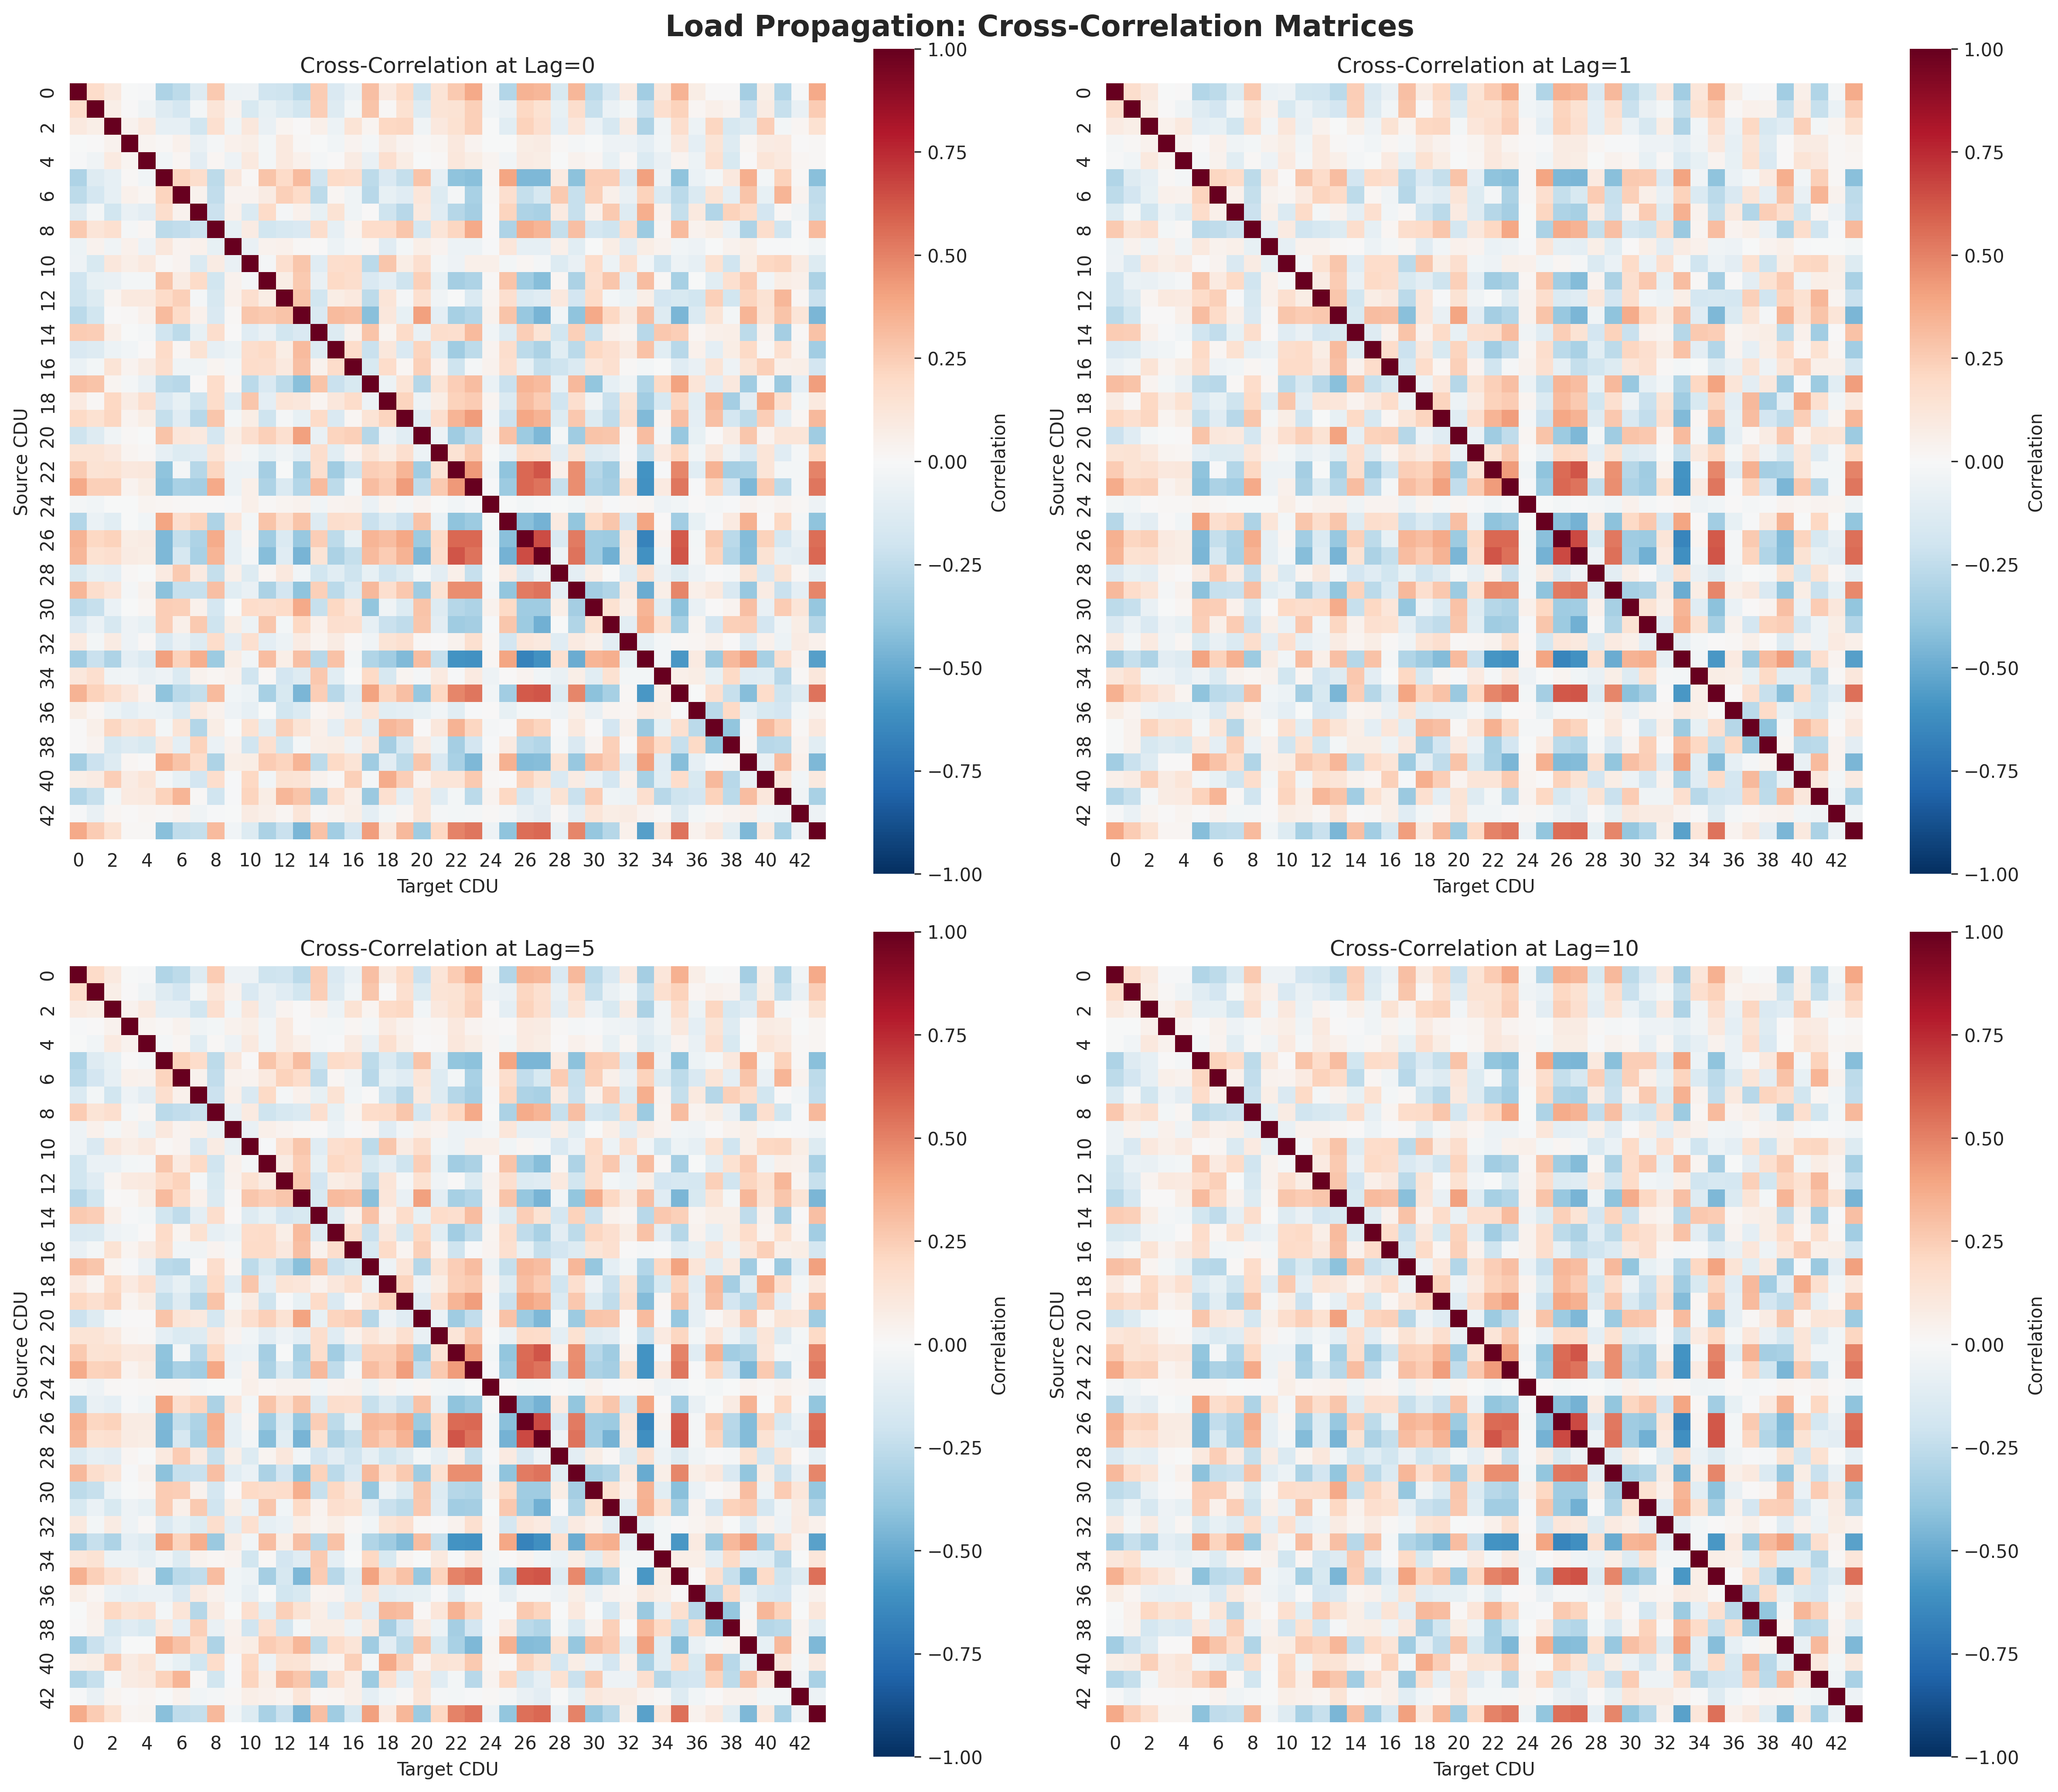

In [28]:
# Load Propagation Analysis - Cross-Correlation Matrices
print("\nGenerating cross-correlation matrices...")
load_analyzer.create_cross_correlation_matrix(lags=[0, 1, 5, 10], max_lag=20)

# Display the result
display(Image(filename=f'{LOAD_PROPAGATION_DIR}/cross_correlation_matrices.png'))


Analyzing attenuation with distance...

Analyzing propagation from CDU 0 (parallelized)...

Analyzing propagation from CDU 11 (parallelized)...

Analyzing propagation from CDU 22 (parallelized)...

Analyzing propagation from CDU 33 (parallelized)...
Saved attenuation analysis to ../results/lassen/data_analysis/spatial_correlation/load_propagation


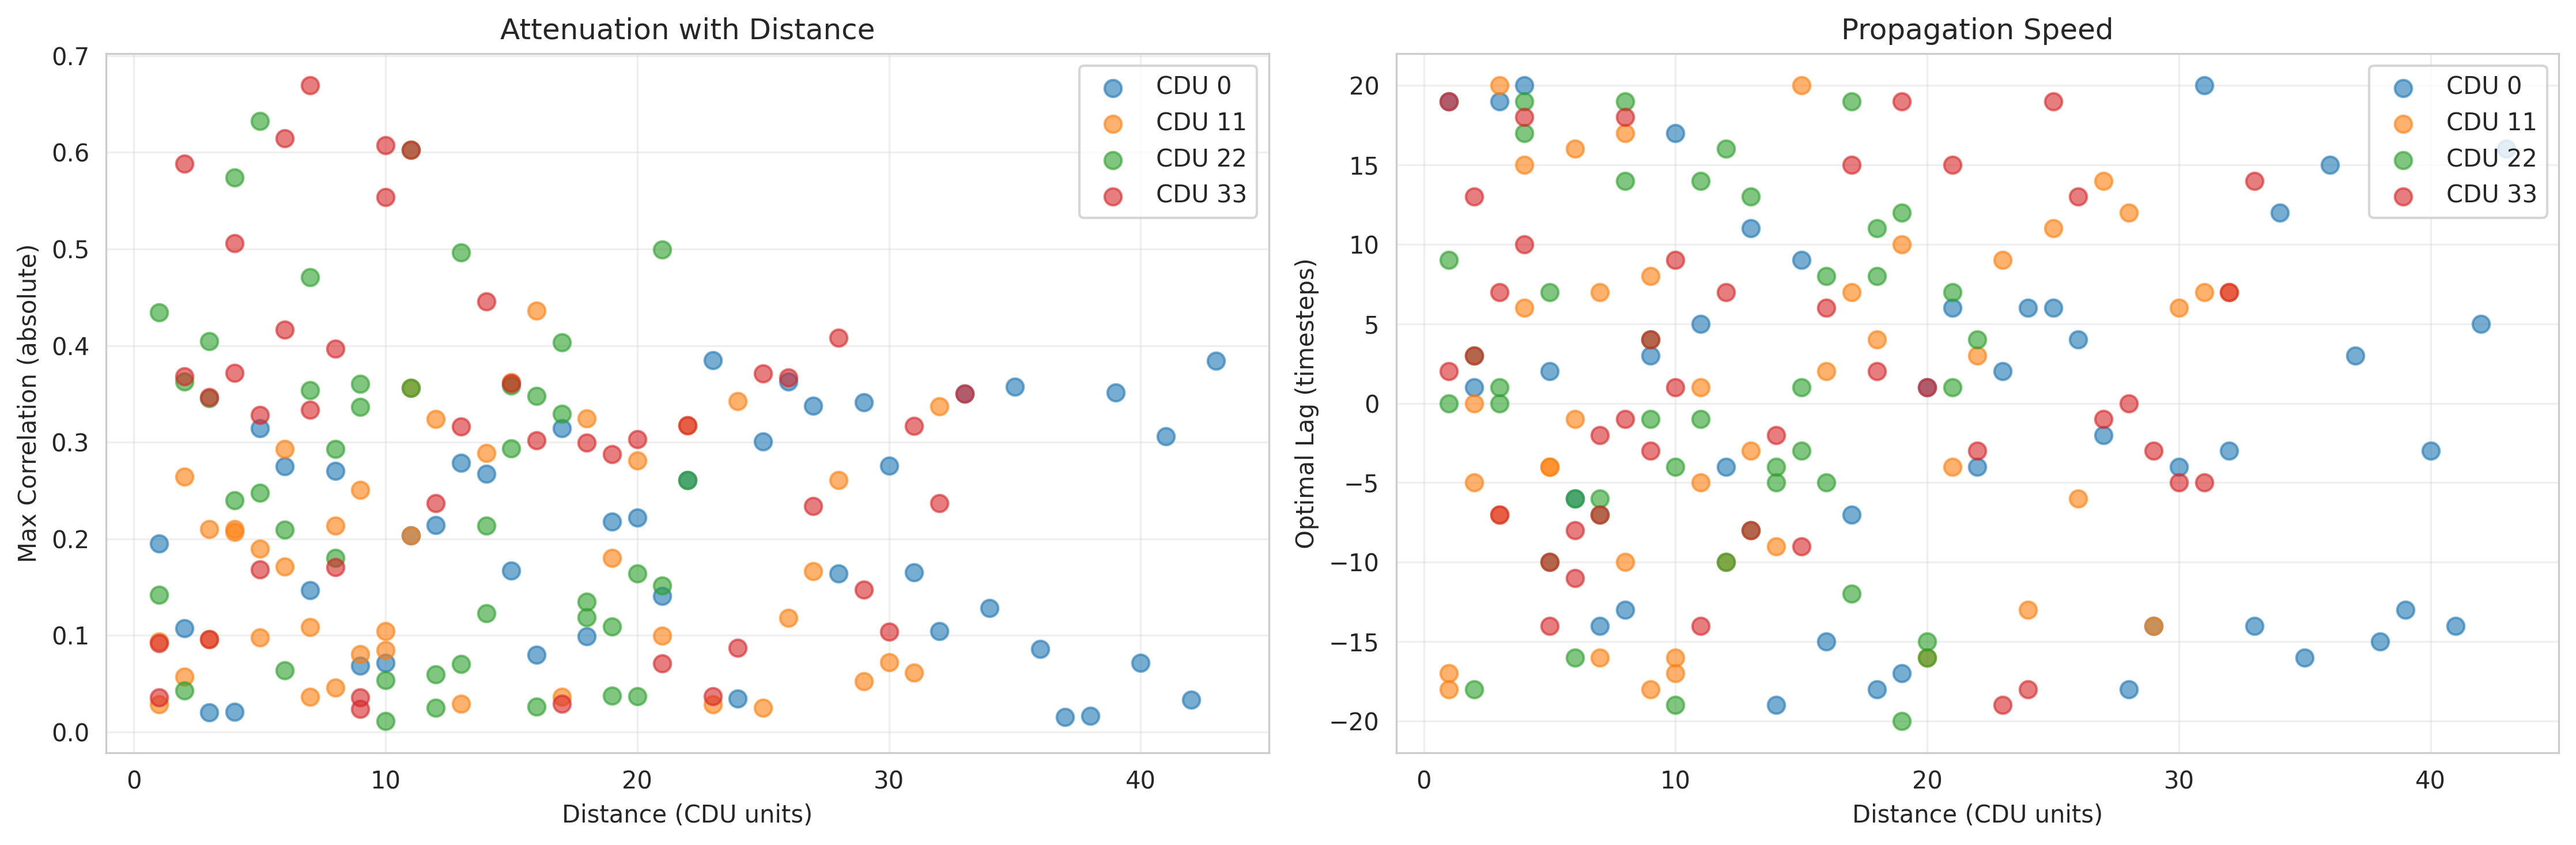

In [29]:
# Load Propagation Analysis - Attenuation with Distance
print("\nAnalyzing attenuation with distance...")
load_analyzer.analyze_attenuation_with_distance()

# Display the result
display(Image(filename=f'{LOAD_PROPAGATION_DIR}/attenuation_analysis.png'))

In [30]:
# Basic Spatial Correlation Analysis - Initialize
print("="*80)
print("BASIC SPATIAL CORRELATION ANALYSIS")
print("="*80)

spatial_analyzer = SpatialCorrelationAnalyzer(
    num_cdus=NUM_CDUS,
    n_workers=N_WORKERS
)

# Metrics to analyze (from your output list)
metrics_to_analyze = [
    'V_flow_prim_GPM', 'V_flow_sec_GPM', 'W_flow_CDUP_kW',
    'T_prim_s_C', 'T_prim_r_C', 'T_sec_s_C', 'T_sec_r_C',
    'p_prim_s_psig', 'p_prim_r_psig', 'p_sec_s_psig', 'p_sec_r_psig'
]

print(f"Analyzing {len(metrics_to_analyze)} metrics")

BASIC SPATIAL CORRELATION ANALYSIS
Analyzing 11 metrics



Detailed analysis for: T_prim_r_C

Analyzing: T_prim_r_C
Computing correlation matrix using 49 workers...

Spatial Correlation Analysis Results:
  Correlation Range: 43 CDUs
  Decay Rate: -0.0031
  Decay R²: 0.3270
  Nearby Correlation (≤5 CDUs): 0.9028
  Distant Correlation (>5 CDUs): 0.8714
  Clustering Ratio: 1.0361
  Hypothesis Supported: True
Saved correlation matrix to ../results/lassen/data_analysis/spatial_correlation/basic_correlations/T_prim_r_C_correlation_matrix.png


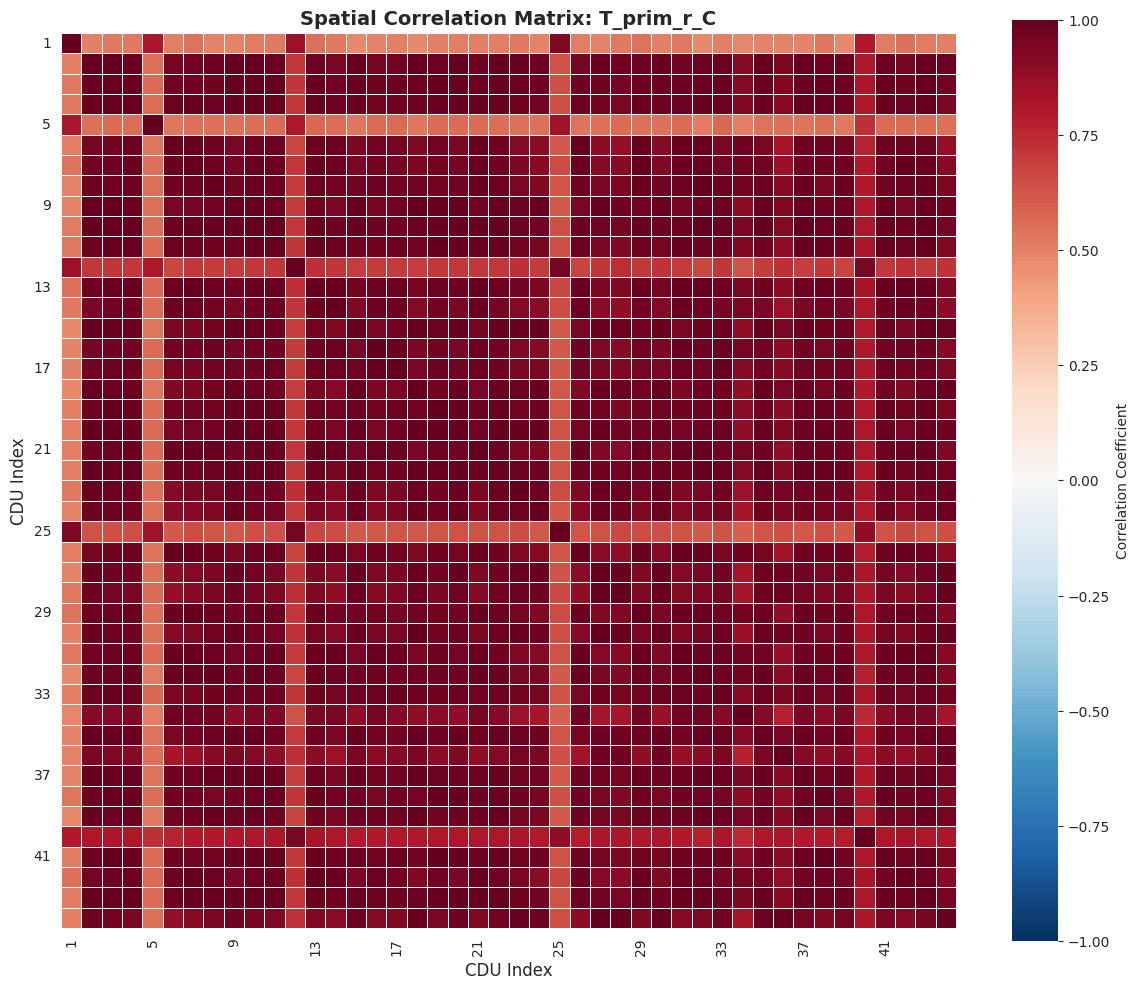

Saved correlation vs distance plot to ../results/lassen/data_analysis/spatial_correlation/basic_correlations/T_prim_r_C_correlation_vs_distance.png


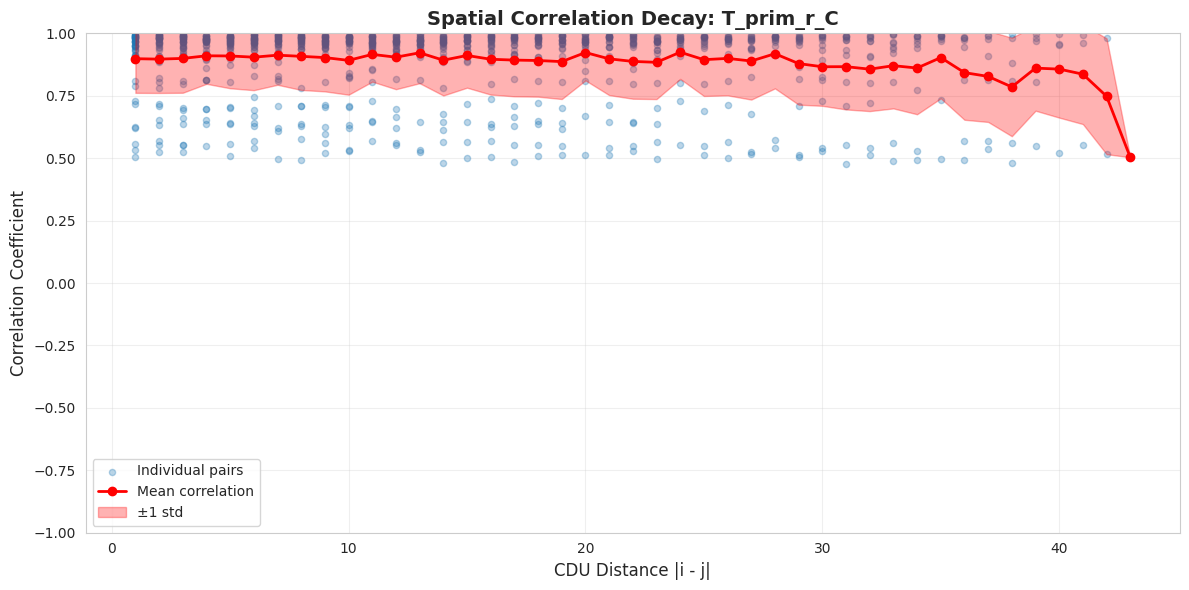

In [32]:
# Basic Spatial Correlation - Single Metric Example
# Analyze one metric in detail as an example
example_metric = 'T_prim_r_C'  # Primary return temperature

print(f"\nDetailed analysis for: {example_metric}")
result = spatial_analyzer.analyze_metric(
    data=df_sim,
    metric=example_metric,
    method='pearson',
    save_dir=BASIC_CORRELATION_DIR
)

# Display correlation matrix
# display(Image(filename=f'{BASIC_CORRELATION_DIR}/{example_metric}_correlation_matrix.png'));

# Display correlation vs distance
# display(Image(filename=f'{BASIC_CORRELATION_DIR}/{example_metric}_correlation_vs_distance.png'))

## Basic Spatial Correlation Analysis


Analyzing all metrics...

Analyzing: V_flow_prim_GPM
Computing correlation matrix using 49 workers...

Spatial Correlation Analysis Results:
  Correlation Range: 42 CDUs
  Decay Rate: -0.0023
  Decay R²: 0.0168
  Nearby Correlation (≤5 CDUs): 0.2694
  Distant Correlation (>5 CDUs): 0.2449
  Clustering Ratio: 1.1001
  Hypothesis Supported: False
Saved correlation matrix to ../results/lassen/data_analysis/spatial_correlation/basic_correlations/V_flow_prim_GPM_correlation_matrix.png


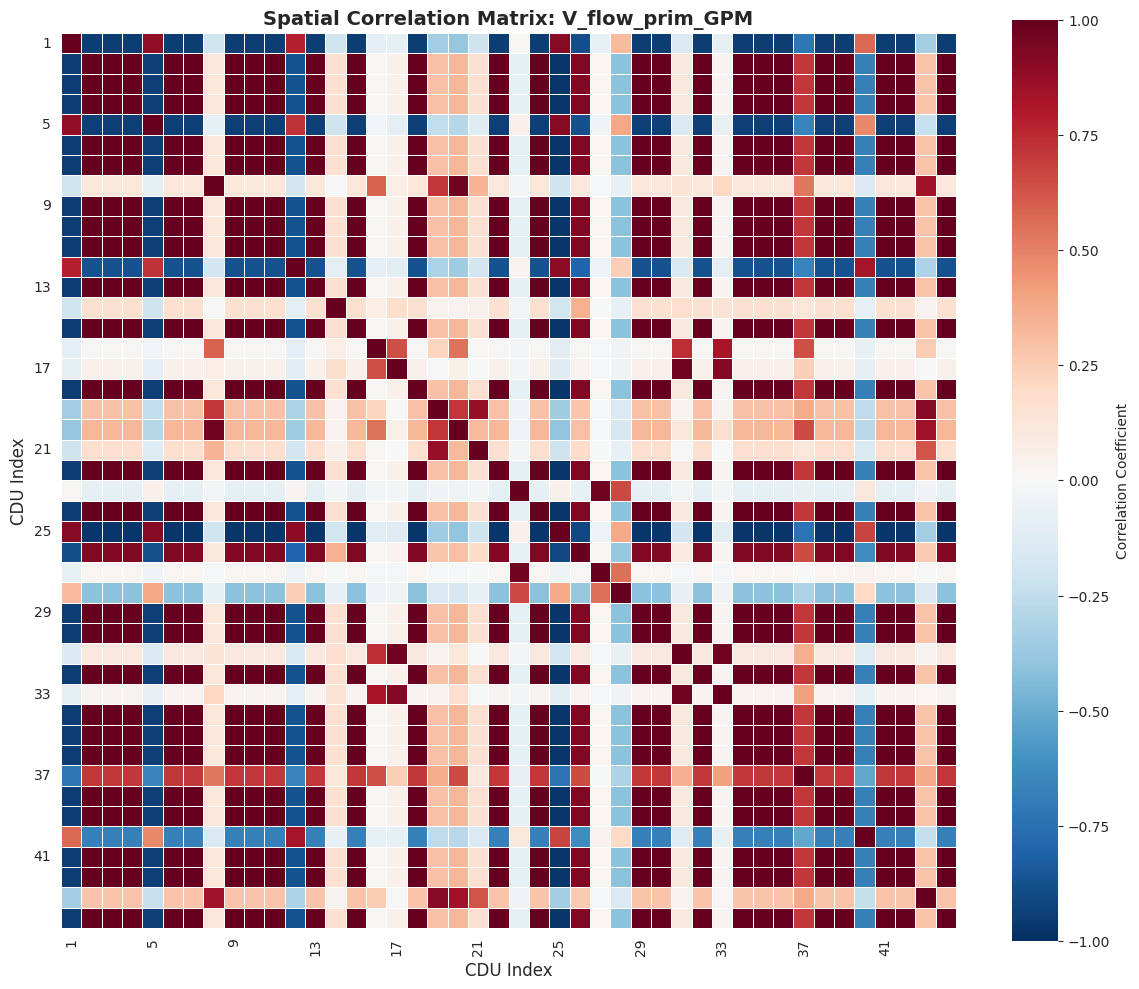

Saved correlation vs distance plot to ../results/lassen/data_analysis/spatial_correlation/basic_correlations/V_flow_prim_GPM_correlation_vs_distance.png


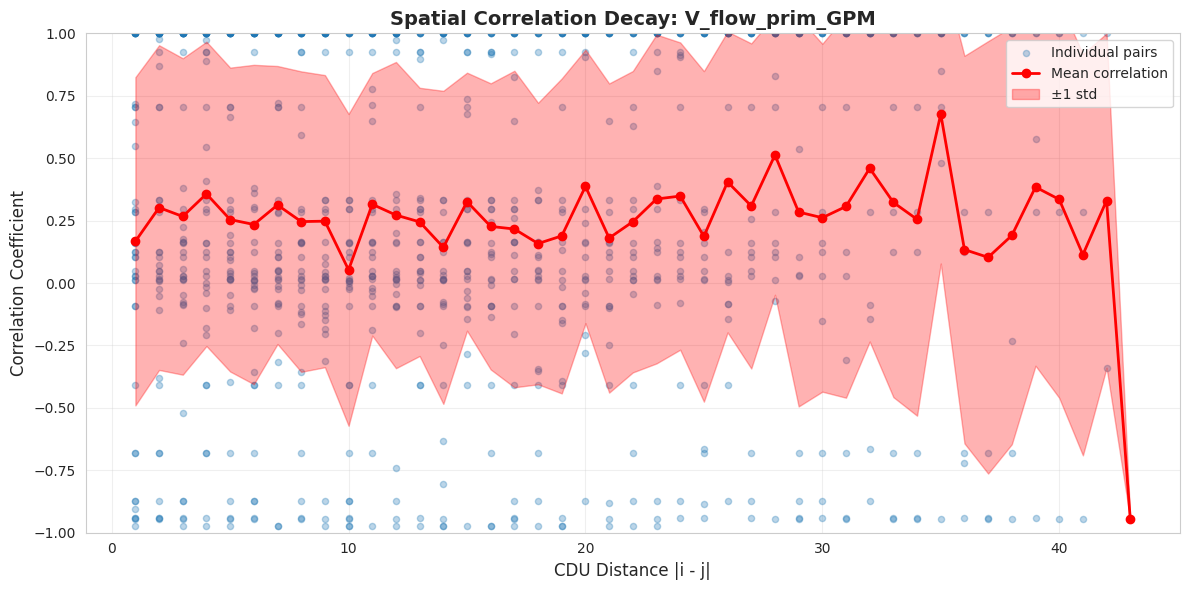


Analyzing: V_flow_sec_GPM
Computing correlation matrix using 49 workers...

Spatial Correlation Analysis Results:
  Correlation Range: 0 CDUs
  Decay Rate: -0.0002
  Decay R²: 0.1530
  Nearby Correlation (≤5 CDUs): 0.1333
  Distant Correlation (>5 CDUs): 0.1317
  Clustering Ratio: 1.0119
  Hypothesis Supported: True
Saved correlation matrix to ../results/lassen/data_analysis/spatial_correlation/basic_correlations/V_flow_sec_GPM_correlation_matrix.png


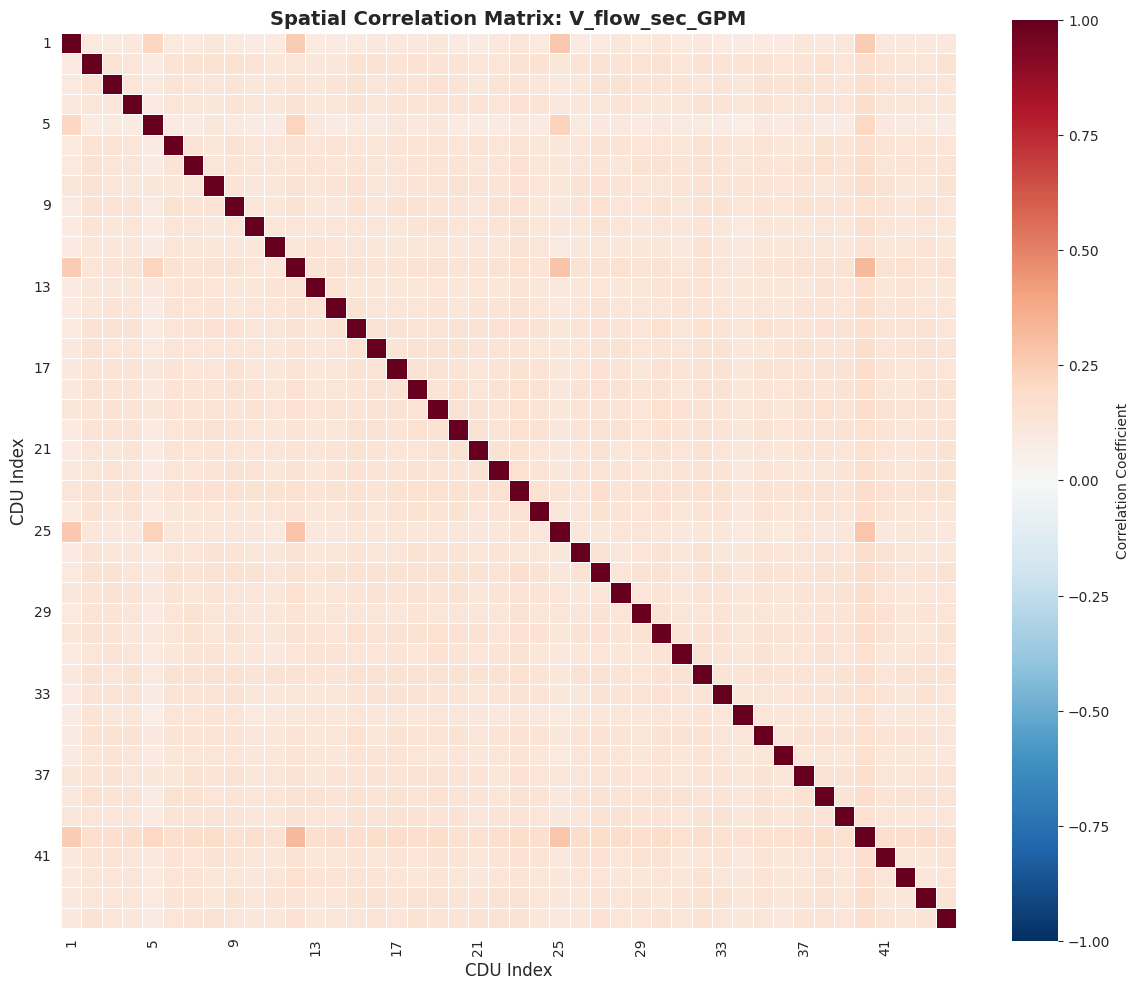

Saved correlation vs distance plot to ../results/lassen/data_analysis/spatial_correlation/basic_correlations/V_flow_sec_GPM_correlation_vs_distance.png


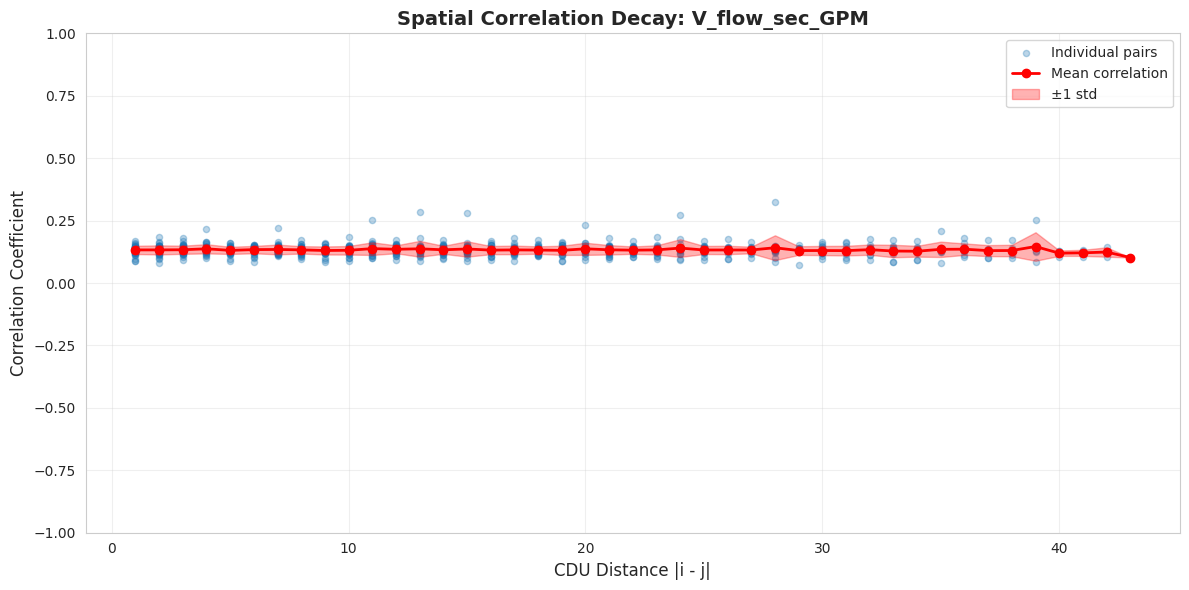


Analyzing: W_flow_CDUP_kW
Computing correlation matrix using 49 workers...

Spatial Correlation Analysis Results:
  Correlation Range: 43 CDUs
  Decay Rate: -0.0013
  Decay R²: 0.1082
  Nearby Correlation (≤5 CDUs): 0.7659
  Distant Correlation (>5 CDUs): 0.7534
  Clustering Ratio: 1.0165
  Hypothesis Supported: True
Saved correlation matrix to ../results/lassen/data_analysis/spatial_correlation/basic_correlations/W_flow_CDUP_kW_correlation_matrix.png


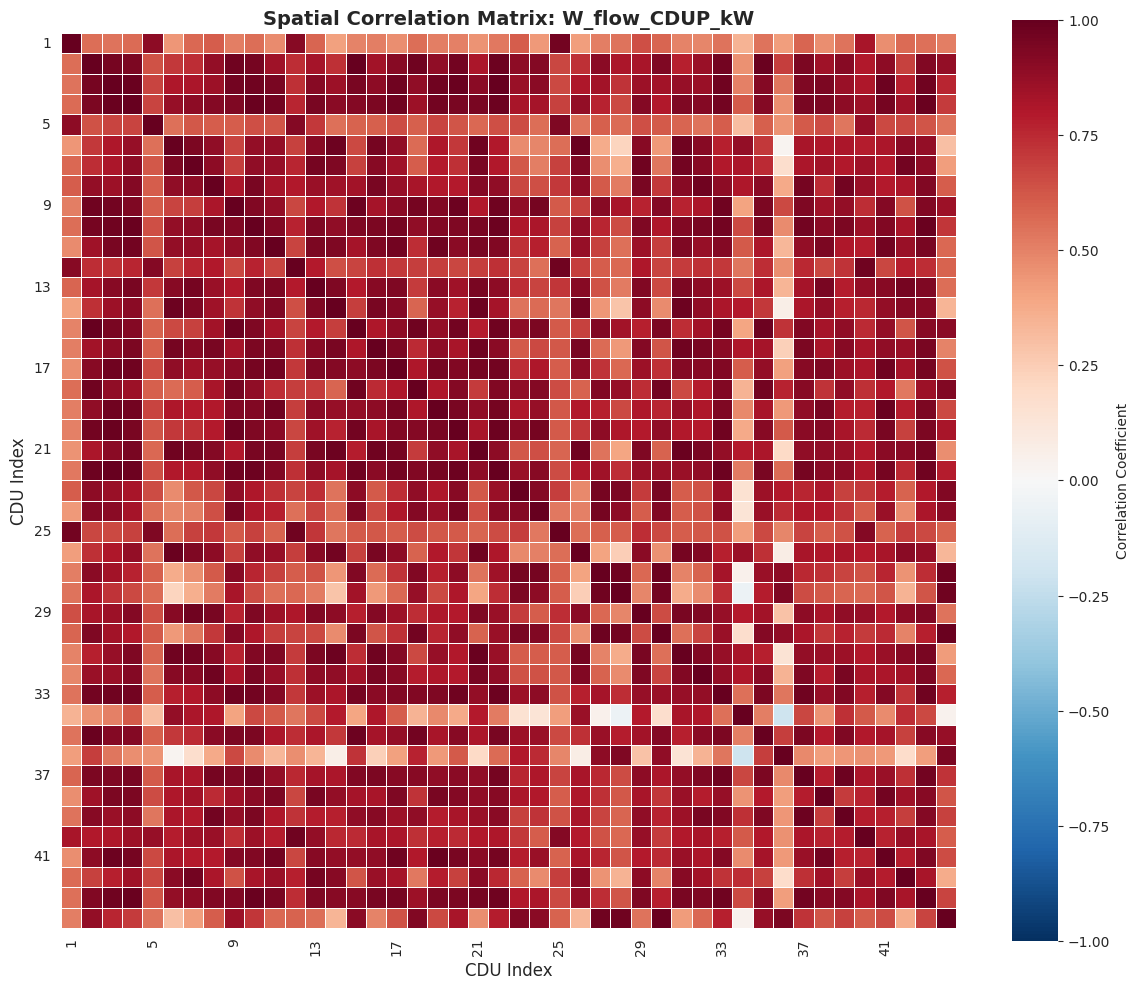

Saved correlation vs distance plot to ../results/lassen/data_analysis/spatial_correlation/basic_correlations/W_flow_CDUP_kW_correlation_vs_distance.png


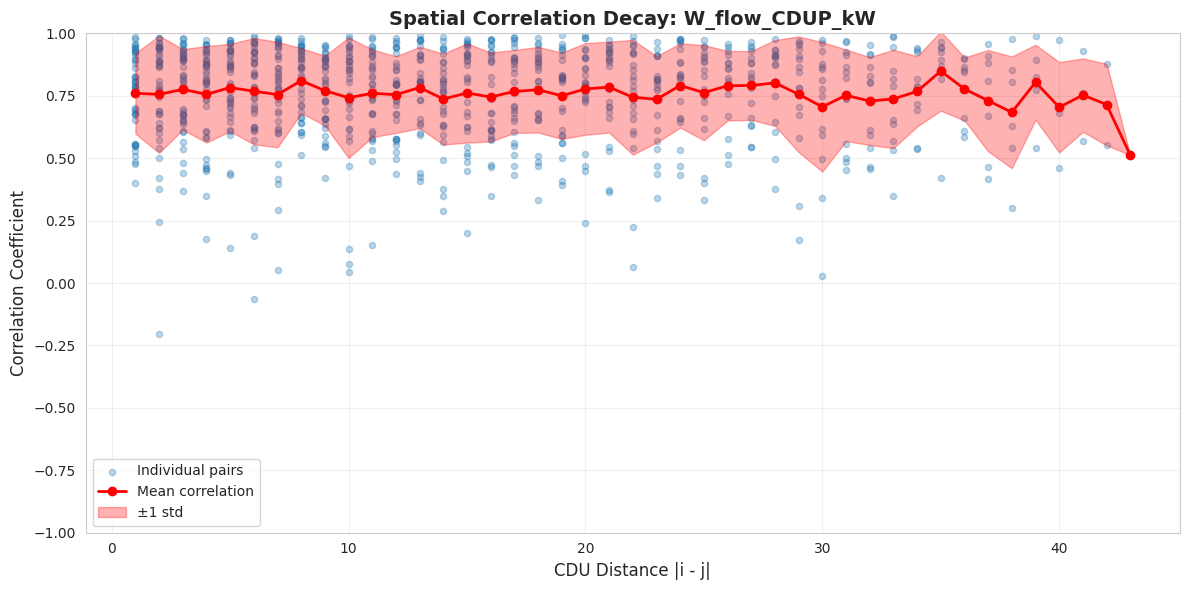


Analyzing: T_prim_s_C
Computing correlation matrix using 49 workers...

Spatial Correlation Analysis Results:
  Correlation Range: 43 CDUs
  Decay Rate: -0.0000
  Decay R²: 0.3904
  Nearby Correlation (≤5 CDUs): 0.9998
  Distant Correlation (>5 CDUs): 0.9996
  Clustering Ratio: 1.0001
  Hypothesis Supported: True
Saved correlation matrix to ../results/lassen/data_analysis/spatial_correlation/basic_correlations/T_prim_s_C_correlation_matrix.png


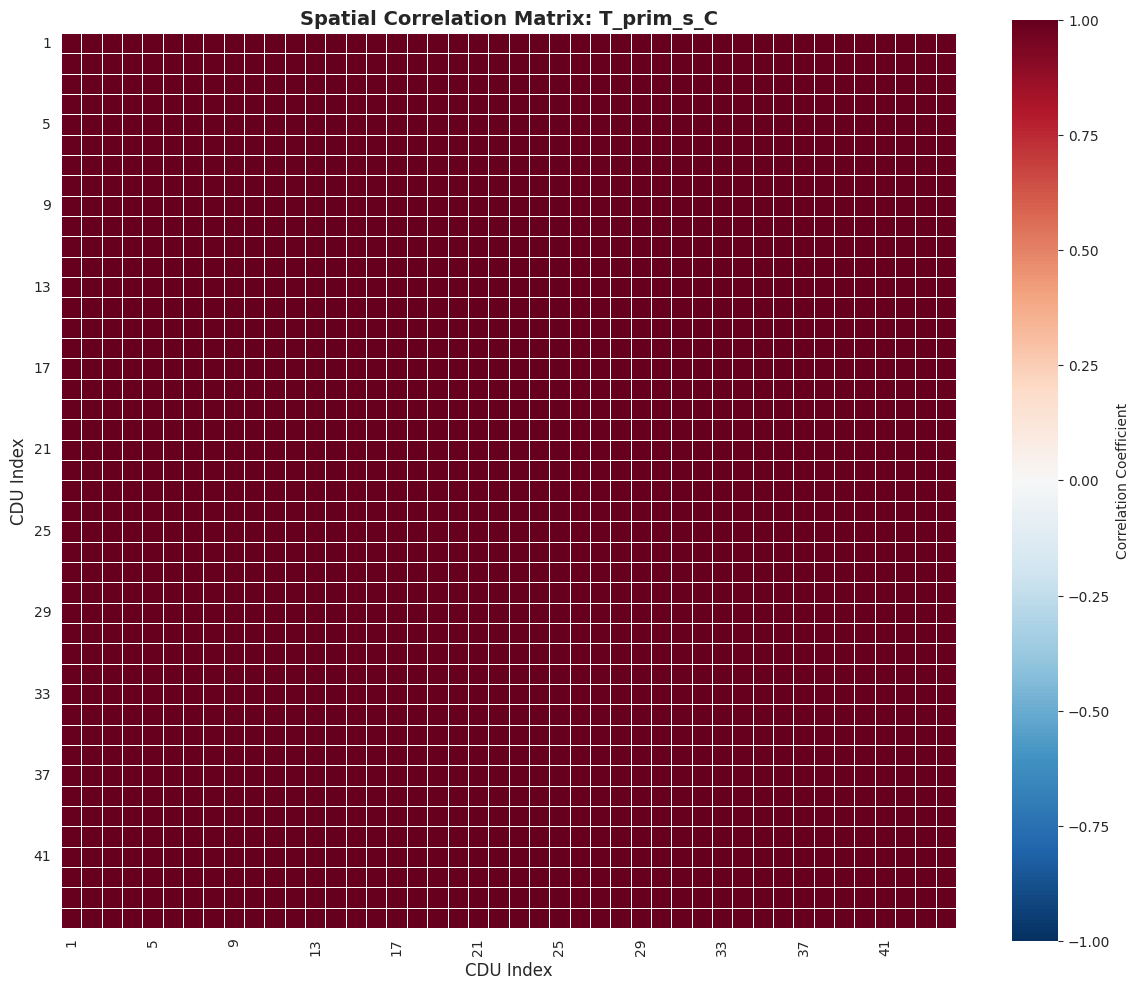

Saved correlation vs distance plot to ../results/lassen/data_analysis/spatial_correlation/basic_correlations/T_prim_s_C_correlation_vs_distance.png


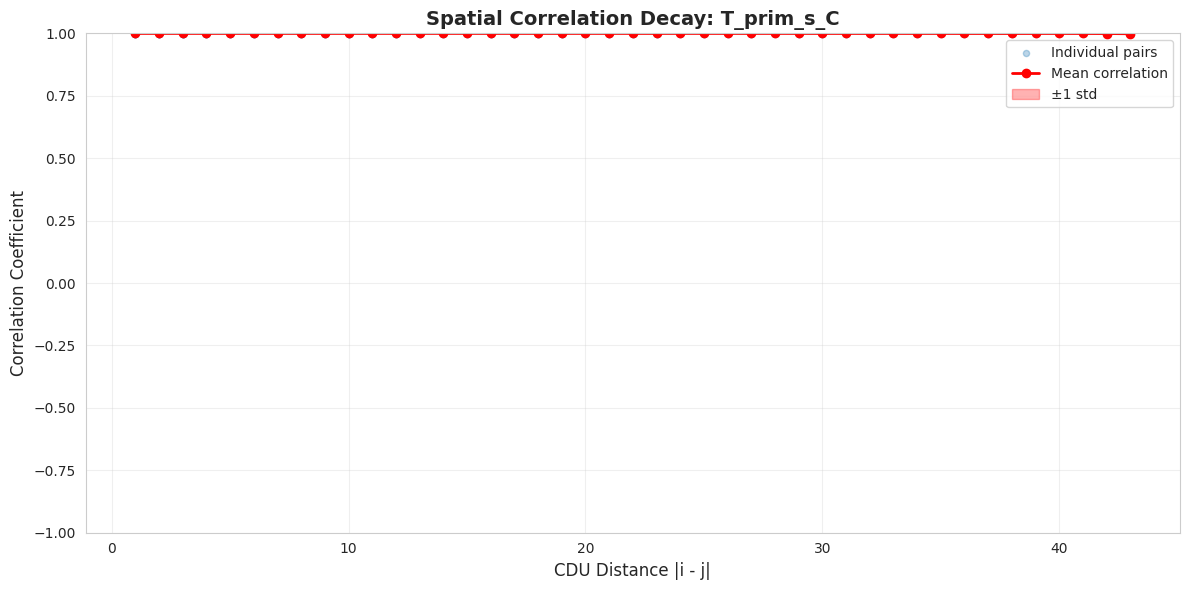


Analyzing: T_prim_r_C
Computing correlation matrix using 49 workers...

Spatial Correlation Analysis Results:
  Correlation Range: 43 CDUs
  Decay Rate: -0.0031
  Decay R²: 0.3270
  Nearby Correlation (≤5 CDUs): 0.9028
  Distant Correlation (>5 CDUs): 0.8714
  Clustering Ratio: 1.0361
  Hypothesis Supported: True
Saved correlation matrix to ../results/lassen/data_analysis/spatial_correlation/basic_correlations/T_prim_r_C_correlation_matrix.png


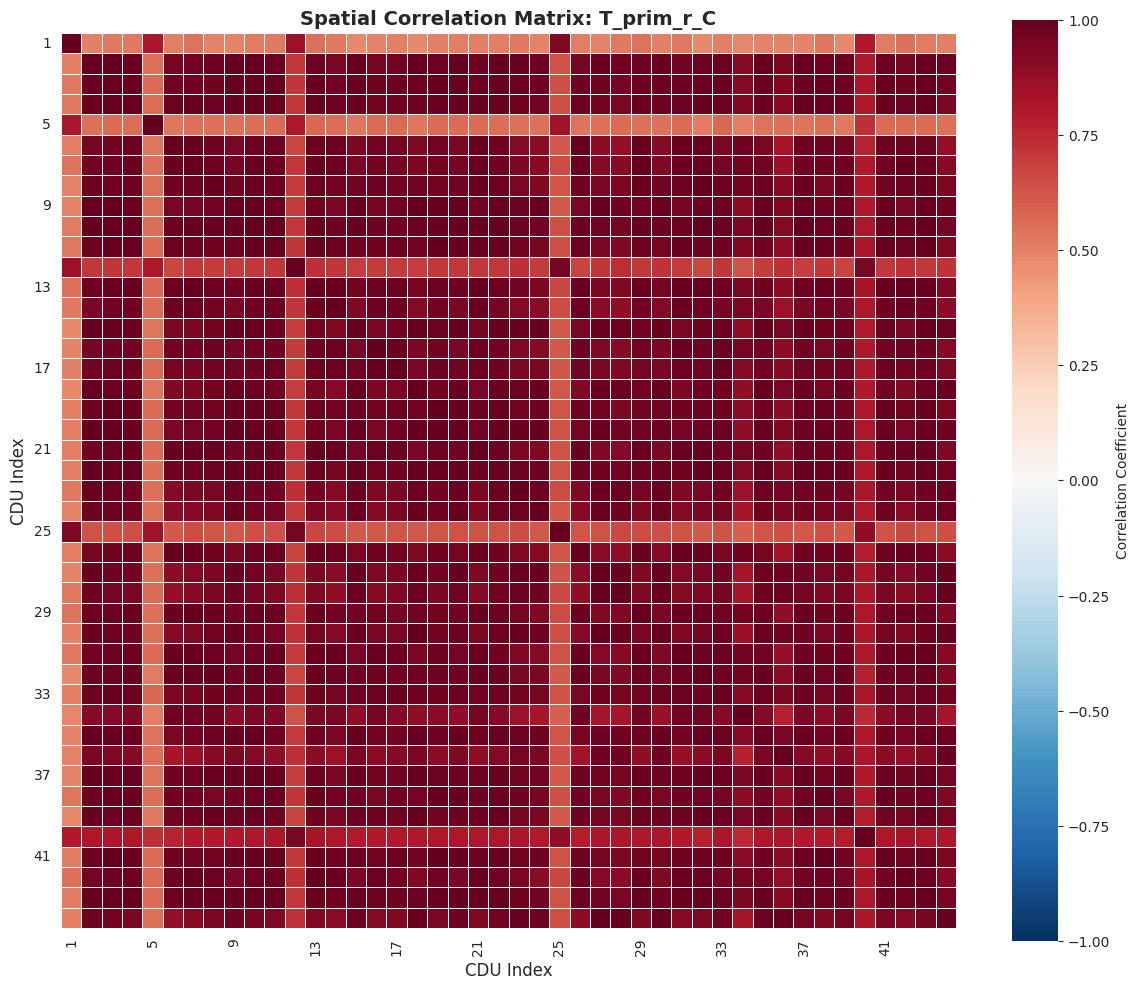

Saved correlation vs distance plot to ../results/lassen/data_analysis/spatial_correlation/basic_correlations/T_prim_r_C_correlation_vs_distance.png


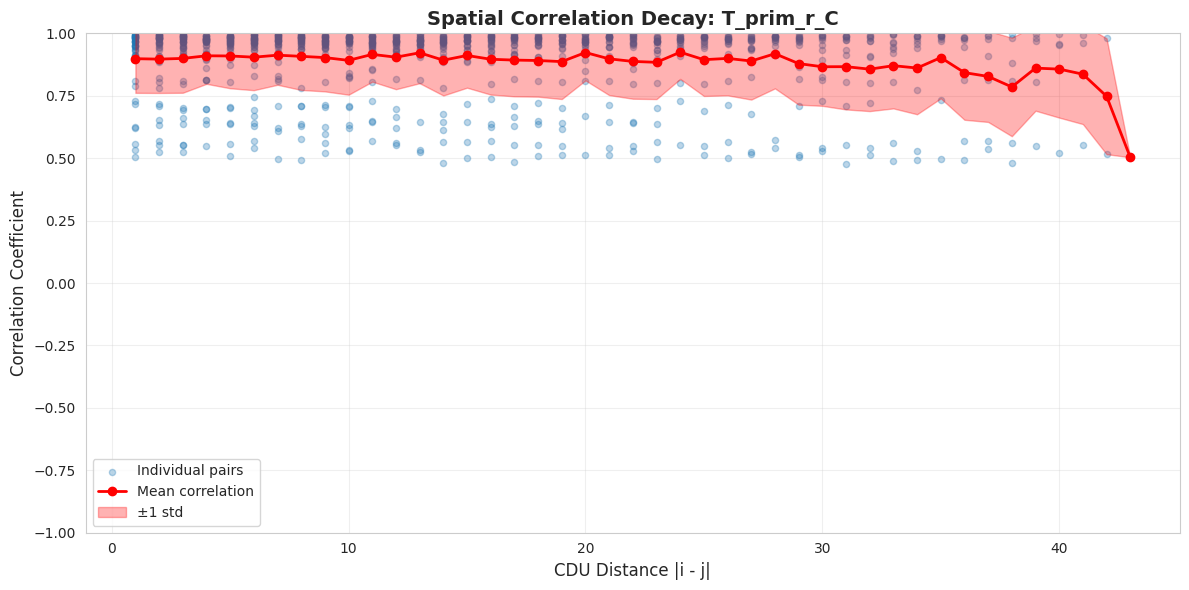


Analyzing: T_sec_s_C
Computing correlation matrix using 49 workers...

Spatial Correlation Analysis Results:
  Correlation Range: 43 CDUs
  Decay Rate: -0.0013
  Decay R²: 0.1072
  Nearby Correlation (≤5 CDUs): 0.7660
  Distant Correlation (>5 CDUs): 0.7536
  Clustering Ratio: 1.0164
  Hypothesis Supported: True
Saved correlation matrix to ../results/lassen/data_analysis/spatial_correlation/basic_correlations/T_sec_s_C_correlation_matrix.png


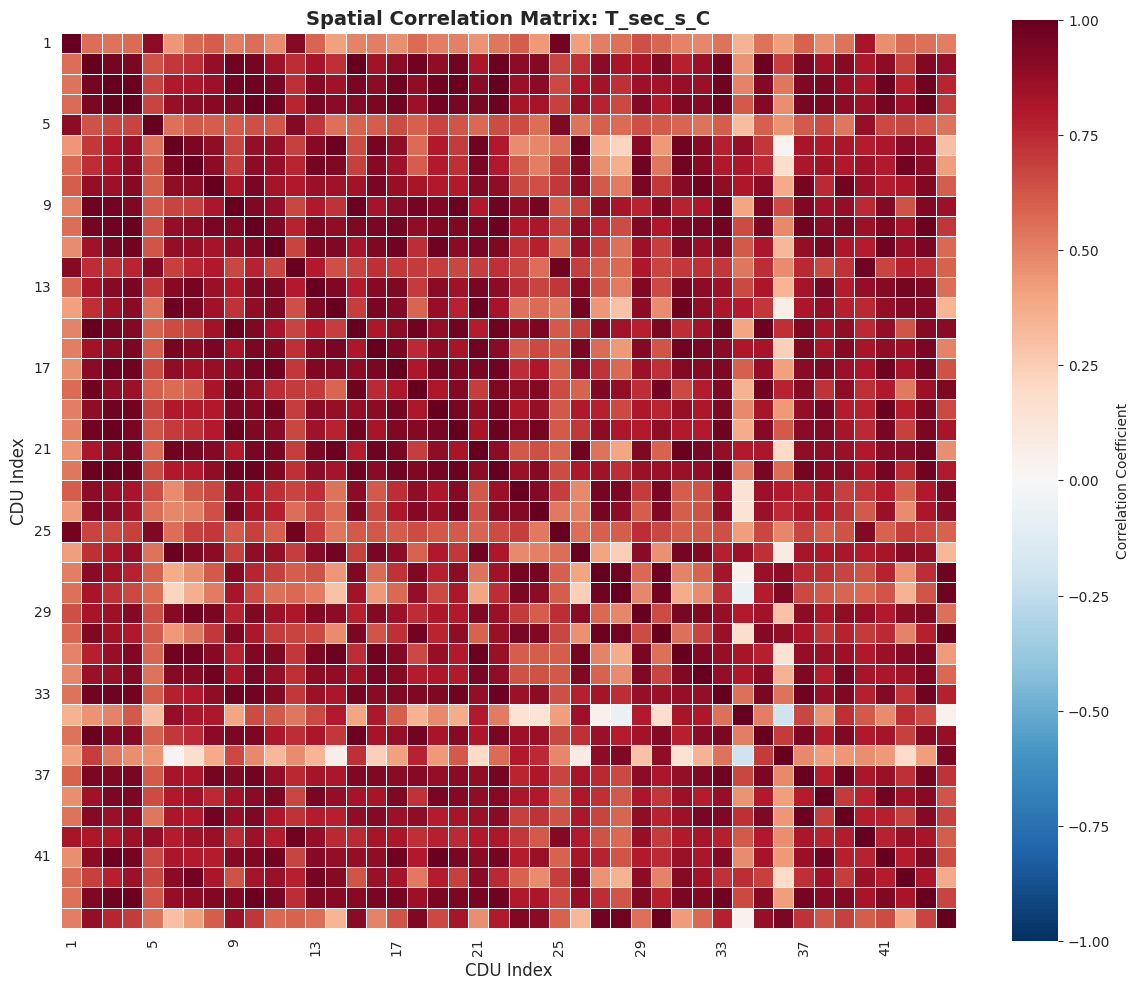

Saved correlation vs distance plot to ../results/lassen/data_analysis/spatial_correlation/basic_correlations/T_sec_s_C_correlation_vs_distance.png


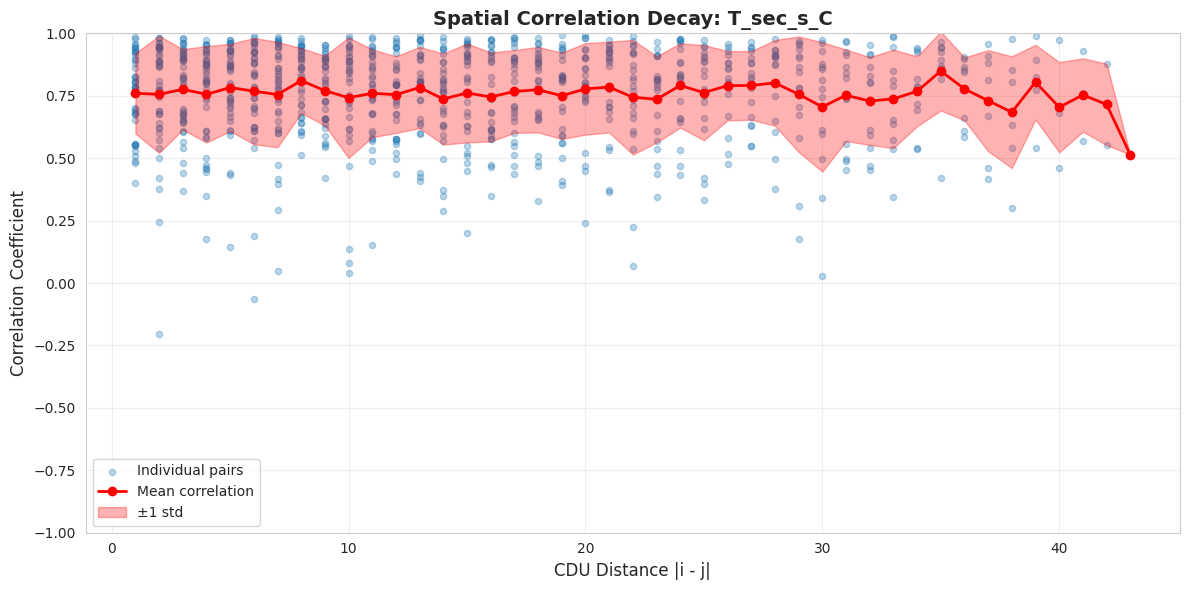


Analyzing: T_sec_r_C
Computing correlation matrix using 49 workers...

Spatial Correlation Analysis Results:
  Correlation Range: 43 CDUs
  Decay Rate: -0.0012
  Decay R²: 0.1007
  Nearby Correlation (≤5 CDUs): 0.7614
  Distant Correlation (>5 CDUs): 0.7495
  Clustering Ratio: 1.0158
  Hypothesis Supported: True
Saved correlation matrix to ../results/lassen/data_analysis/spatial_correlation/basic_correlations/T_sec_r_C_correlation_matrix.png


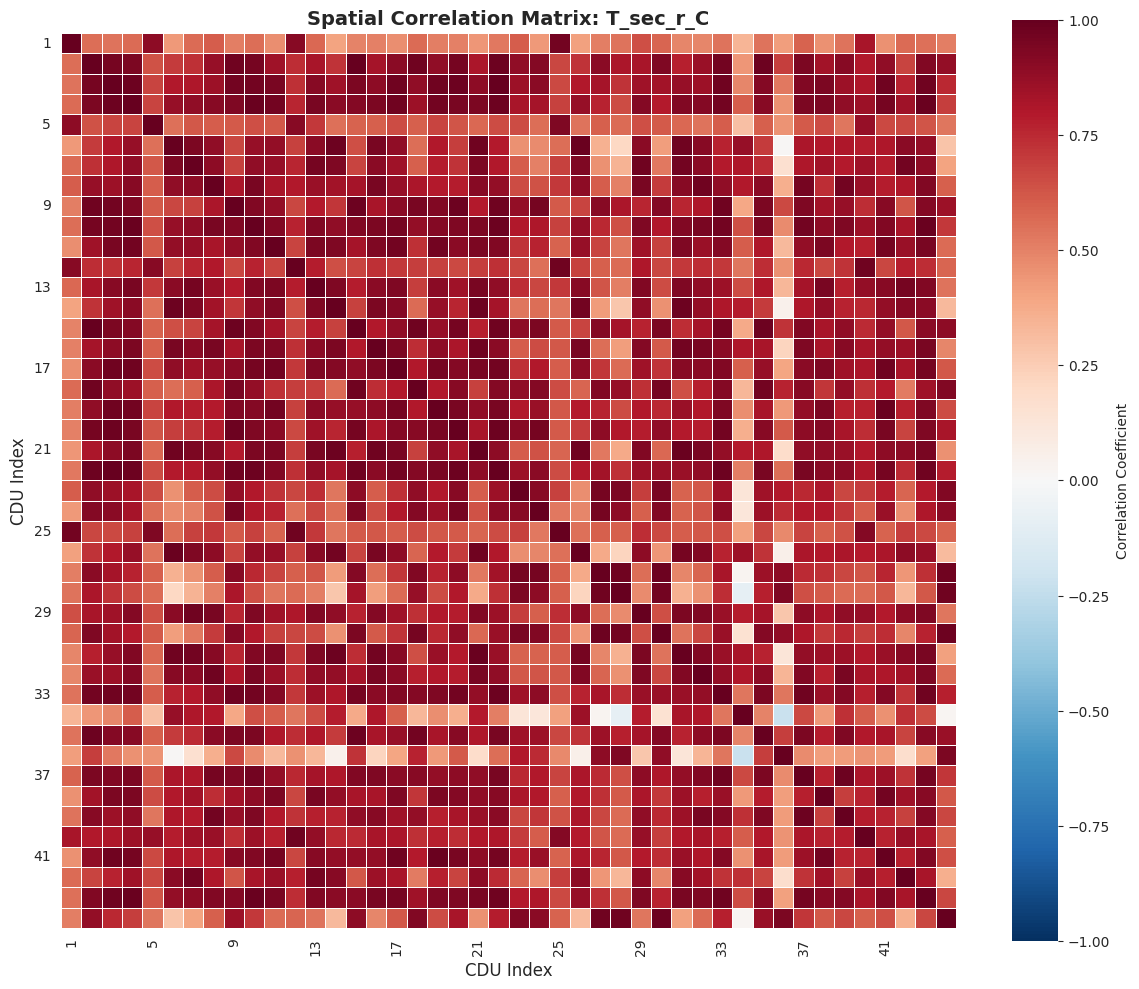

Saved correlation vs distance plot to ../results/lassen/data_analysis/spatial_correlation/basic_correlations/T_sec_r_C_correlation_vs_distance.png


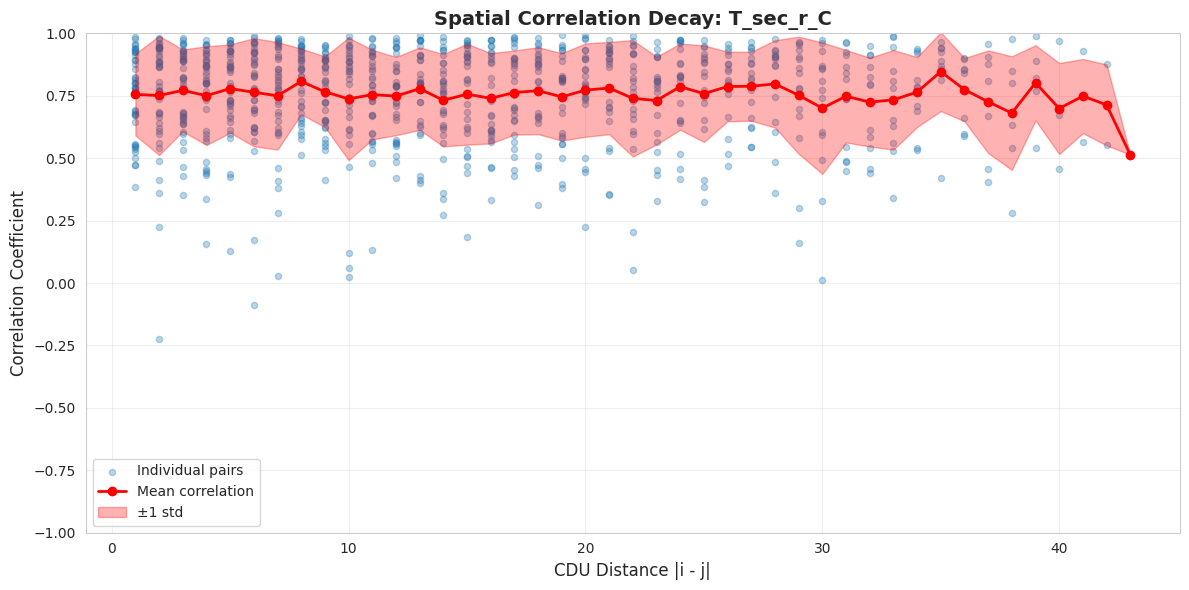


Analyzing: p_prim_s_psig
Computing correlation matrix using 49 workers...

Spatial Correlation Analysis Results:
  Correlation Range: 43 CDUs
  Decay Rate: -0.0000
  Decay R²: 0.4202
  Nearby Correlation (≤5 CDUs): 1.0000
  Distant Correlation (>5 CDUs): 1.0000
  Clustering Ratio: 1.0000
  Hypothesis Supported: True
Saved correlation matrix to ../results/lassen/data_analysis/spatial_correlation/basic_correlations/p_prim_s_psig_correlation_matrix.png


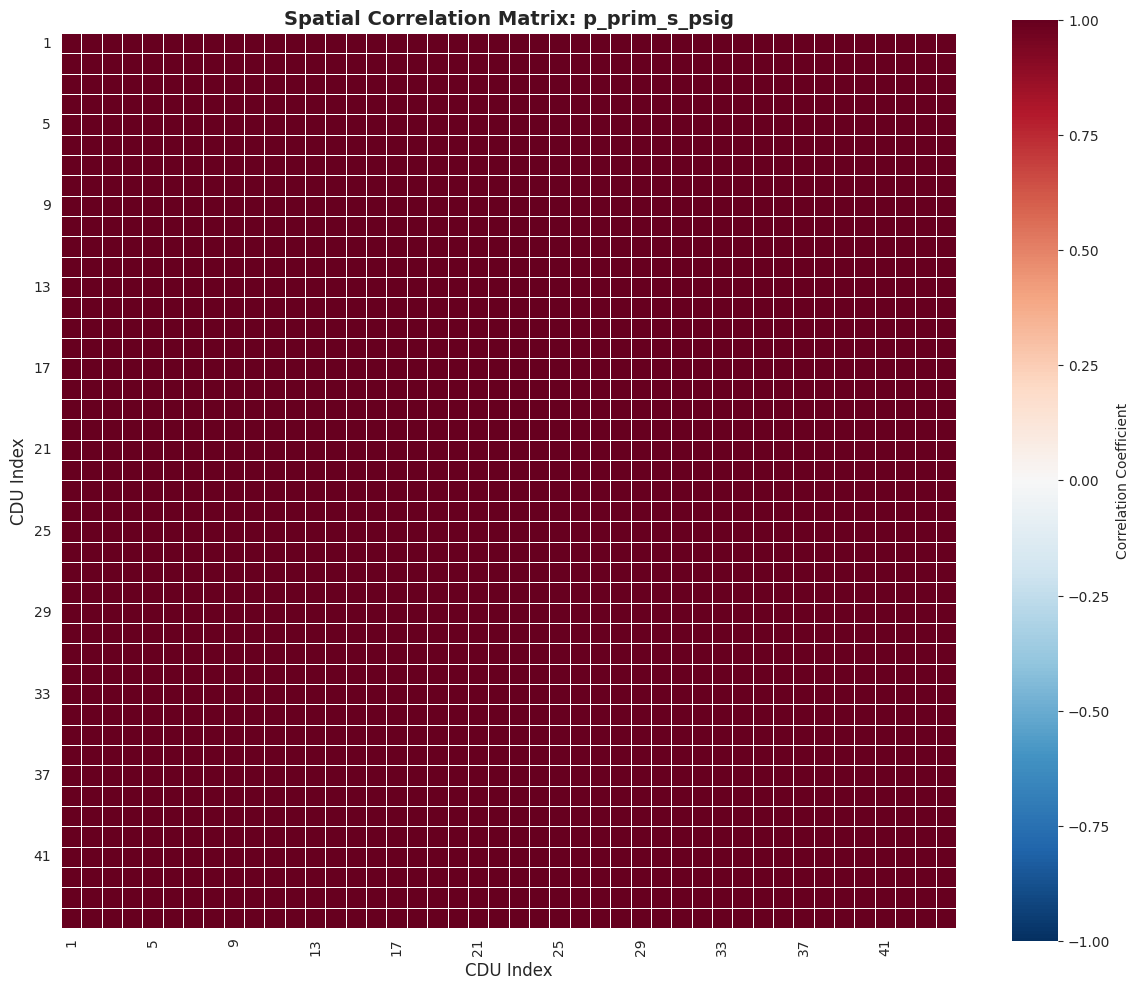

Saved correlation vs distance plot to ../results/lassen/data_analysis/spatial_correlation/basic_correlations/p_prim_s_psig_correlation_vs_distance.png


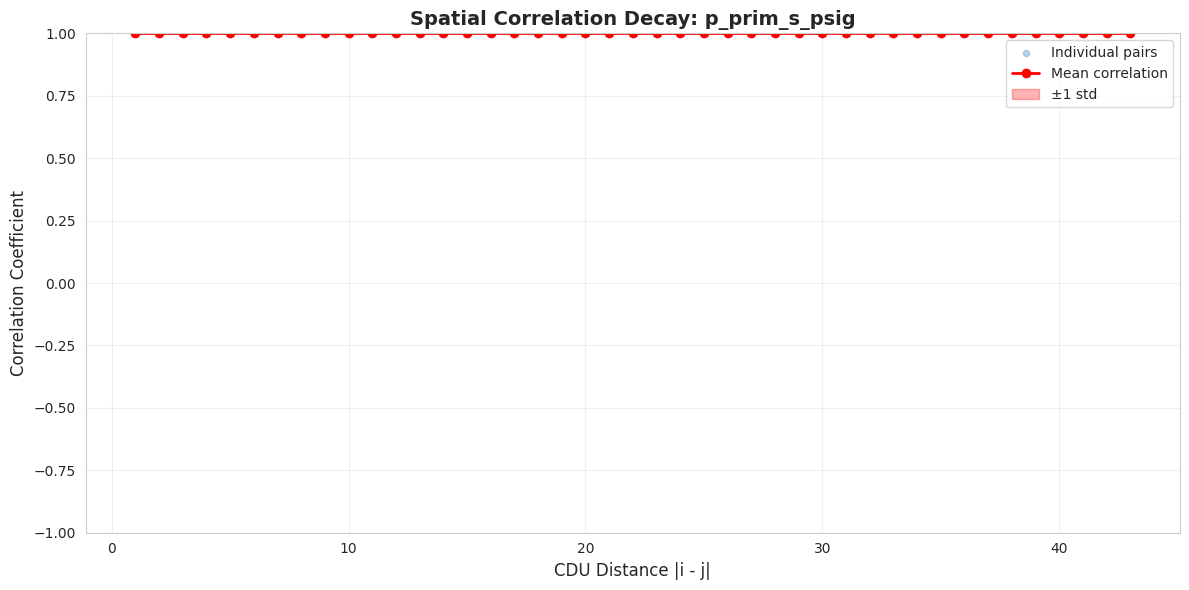


Analyzing: p_prim_r_psig
Computing correlation matrix using 49 workers...

Spatial Correlation Analysis Results:
  Correlation Range: 43 CDUs
  Decay Rate: -0.0000
  Decay R²: 0.3905
  Nearby Correlation (≤5 CDUs): 1.0000
  Distant Correlation (>5 CDUs): 1.0000
  Clustering Ratio: 1.0000
  Hypothesis Supported: True
Saved correlation matrix to ../results/lassen/data_analysis/spatial_correlation/basic_correlations/p_prim_r_psig_correlation_matrix.png


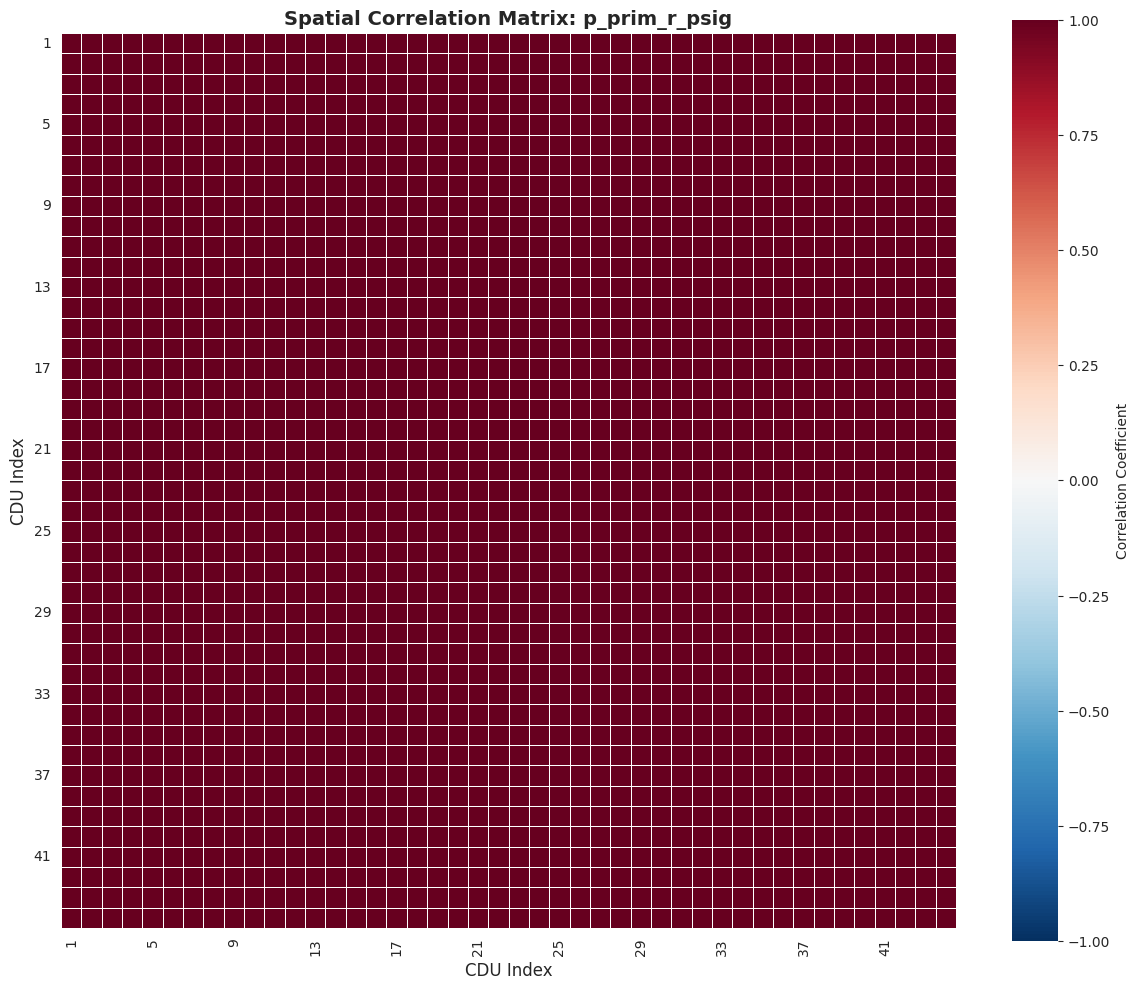

Saved correlation vs distance plot to ../results/lassen/data_analysis/spatial_correlation/basic_correlations/p_prim_r_psig_correlation_vs_distance.png


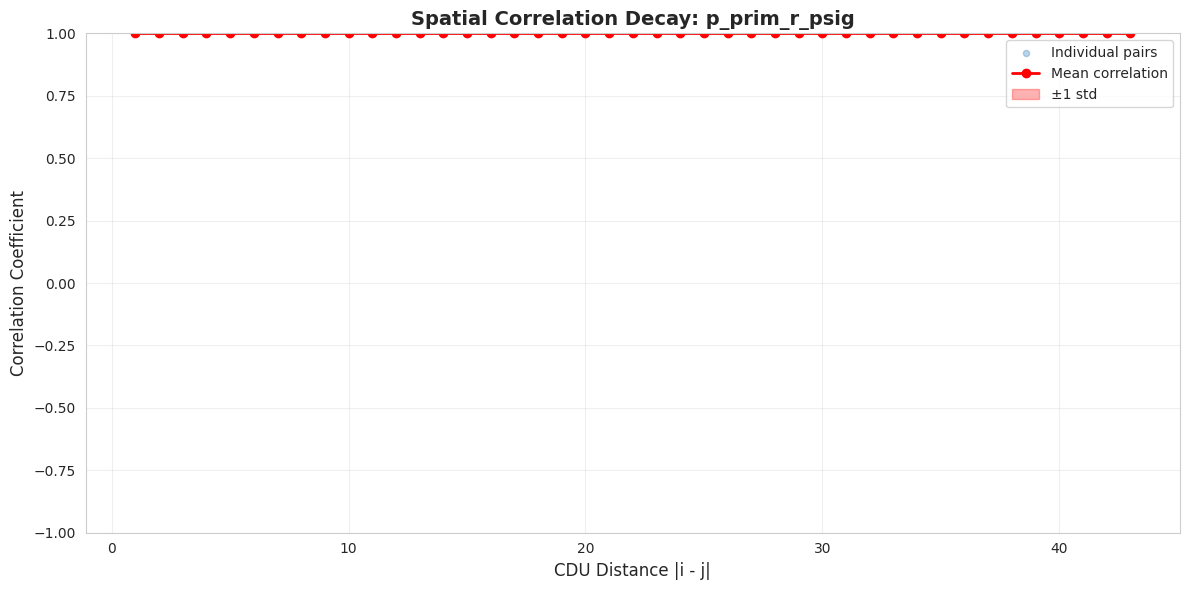


Analyzing: p_sec_s_psig
Computing correlation matrix using 49 workers...

Spatial Correlation Analysis Results:
  Correlation Range: 43 CDUs
  Decay Rate: -0.0018
  Decay R²: 0.2185
  Nearby Correlation (≤5 CDUs): 0.7362
  Distant Correlation (>5 CDUs): 0.7181
  Clustering Ratio: 1.0251
  Hypothesis Supported: True
Saved correlation matrix to ../results/lassen/data_analysis/spatial_correlation/basic_correlations/p_sec_s_psig_correlation_matrix.png


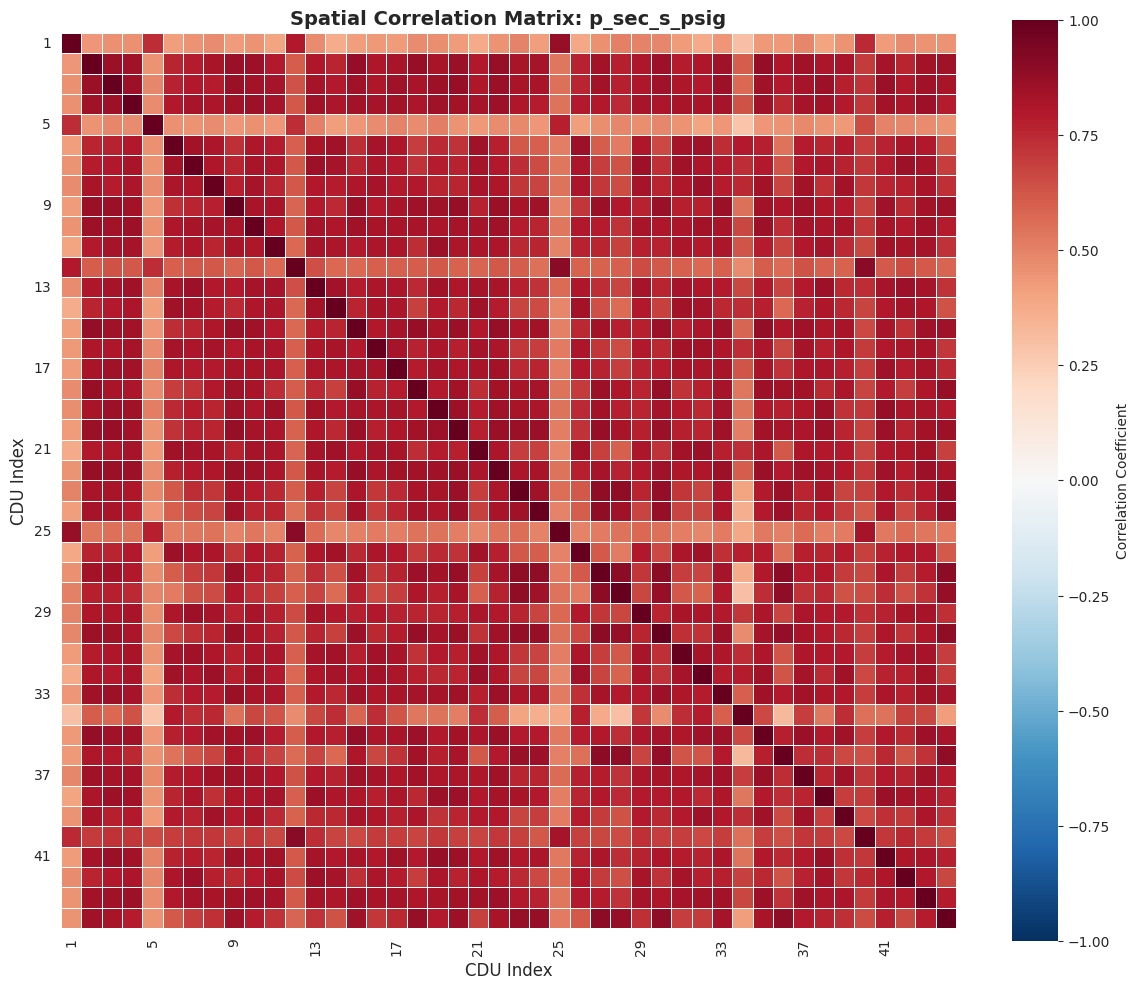

Saved correlation vs distance plot to ../results/lassen/data_analysis/spatial_correlation/basic_correlations/p_sec_s_psig_correlation_vs_distance.png


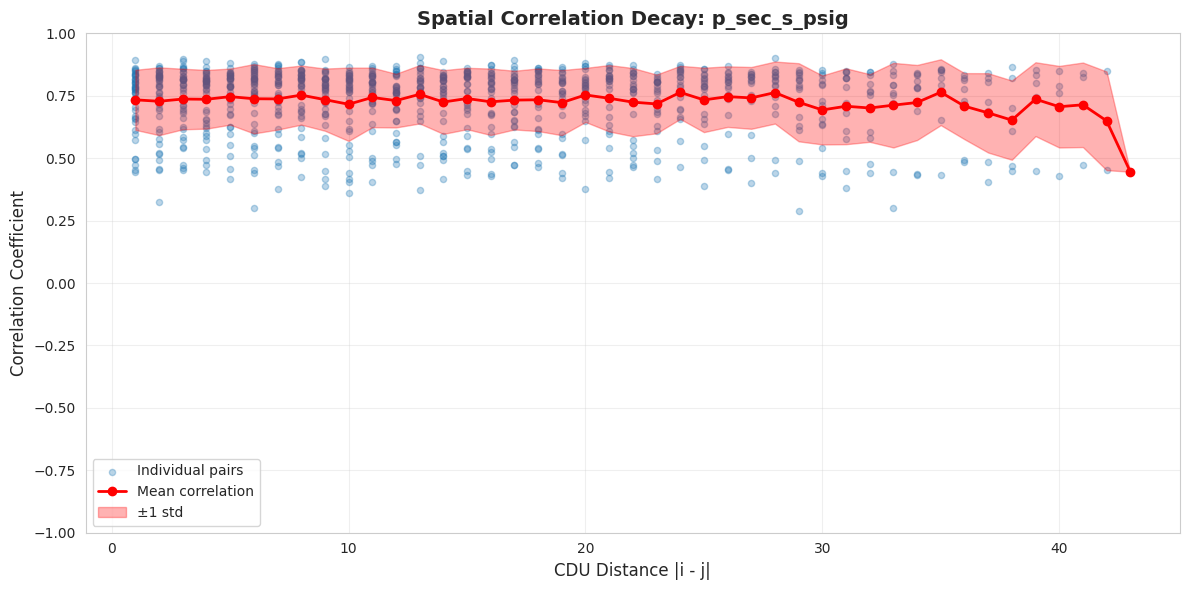


Analyzing: p_sec_r_psig
Computing correlation matrix using 49 workers...

Spatial Correlation Analysis Results:
  Correlation Range: 43 CDUs
  Decay Rate: -0.0018
  Decay R²: 0.2185
  Nearby Correlation (≤5 CDUs): 0.7362
  Distant Correlation (>5 CDUs): 0.7181
  Clustering Ratio: 1.0251
  Hypothesis Supported: True
Saved correlation matrix to ../results/lassen/data_analysis/spatial_correlation/basic_correlations/p_sec_r_psig_correlation_matrix.png


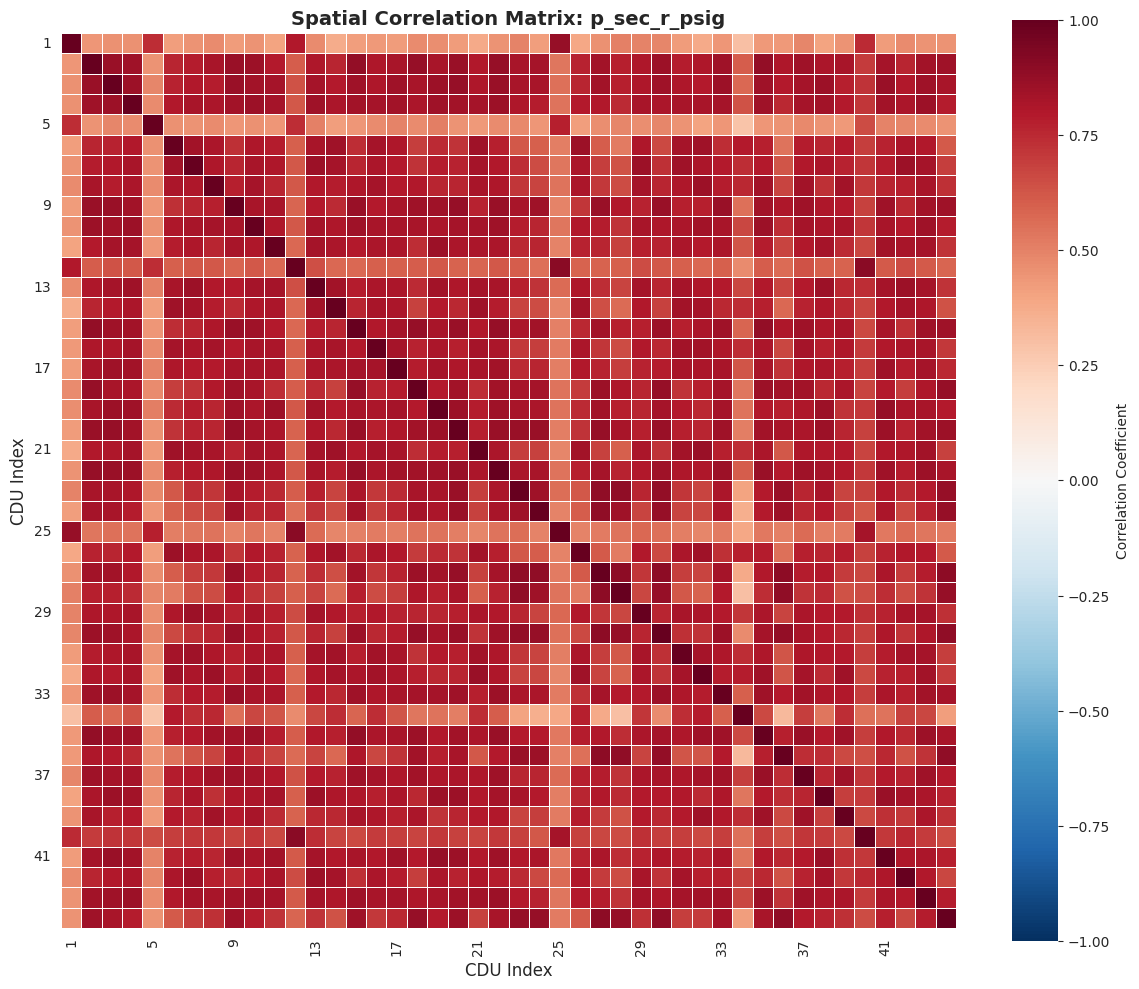

Saved correlation vs distance plot to ../results/lassen/data_analysis/spatial_correlation/basic_correlations/p_sec_r_psig_correlation_vs_distance.png


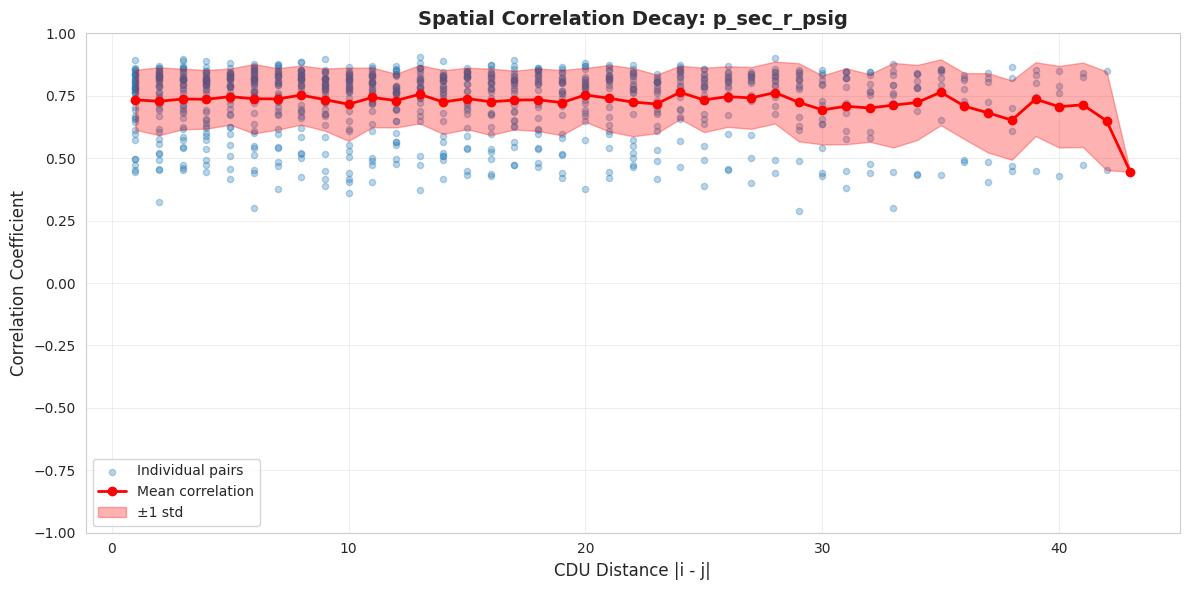

Computing correlation matrix using 49 workers...
Computing correlation matrix using 49 workers...
Computing correlation matrix using 49 workers...
Computing correlation matrix using 49 workers...
Computing correlation matrix using 49 workers...
Computing correlation matrix using 49 workers...
Computing correlation matrix using 49 workers...
Computing correlation matrix using 49 workers...
Computing correlation matrix using 49 workers...
Computing correlation matrix using 49 workers...
Computing correlation matrix using 49 workers...
Saved correlation decay heatmap to ../results/lassen/data_analysis/spatial_correlation/basic_correlations/correlation_decay_heatmap.png


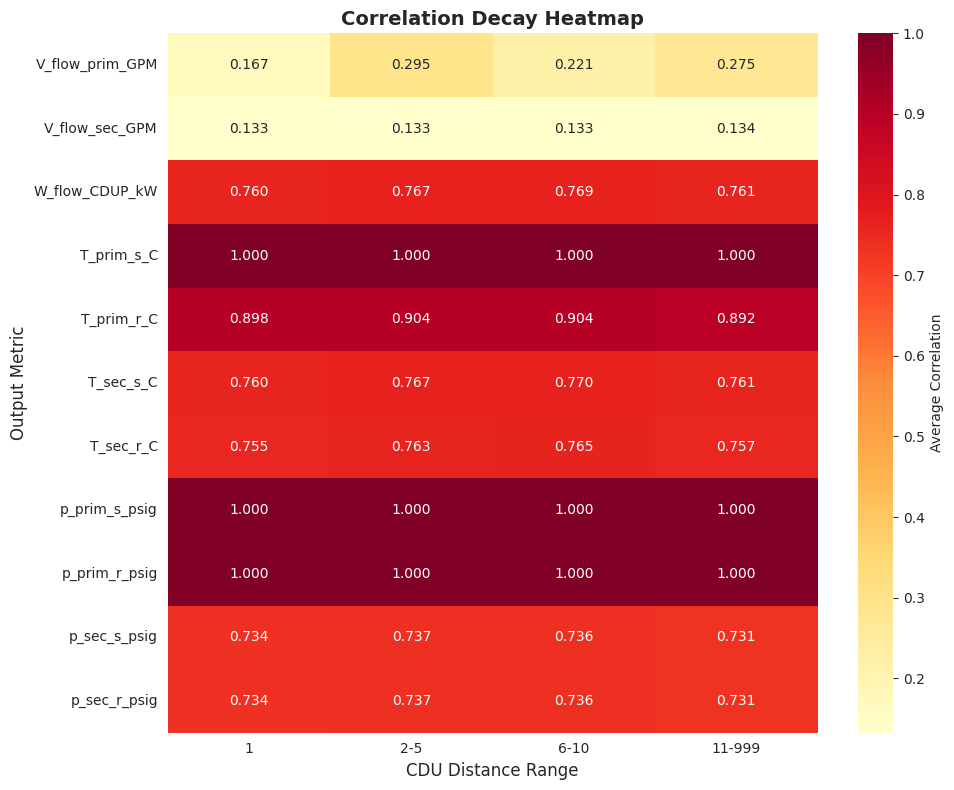

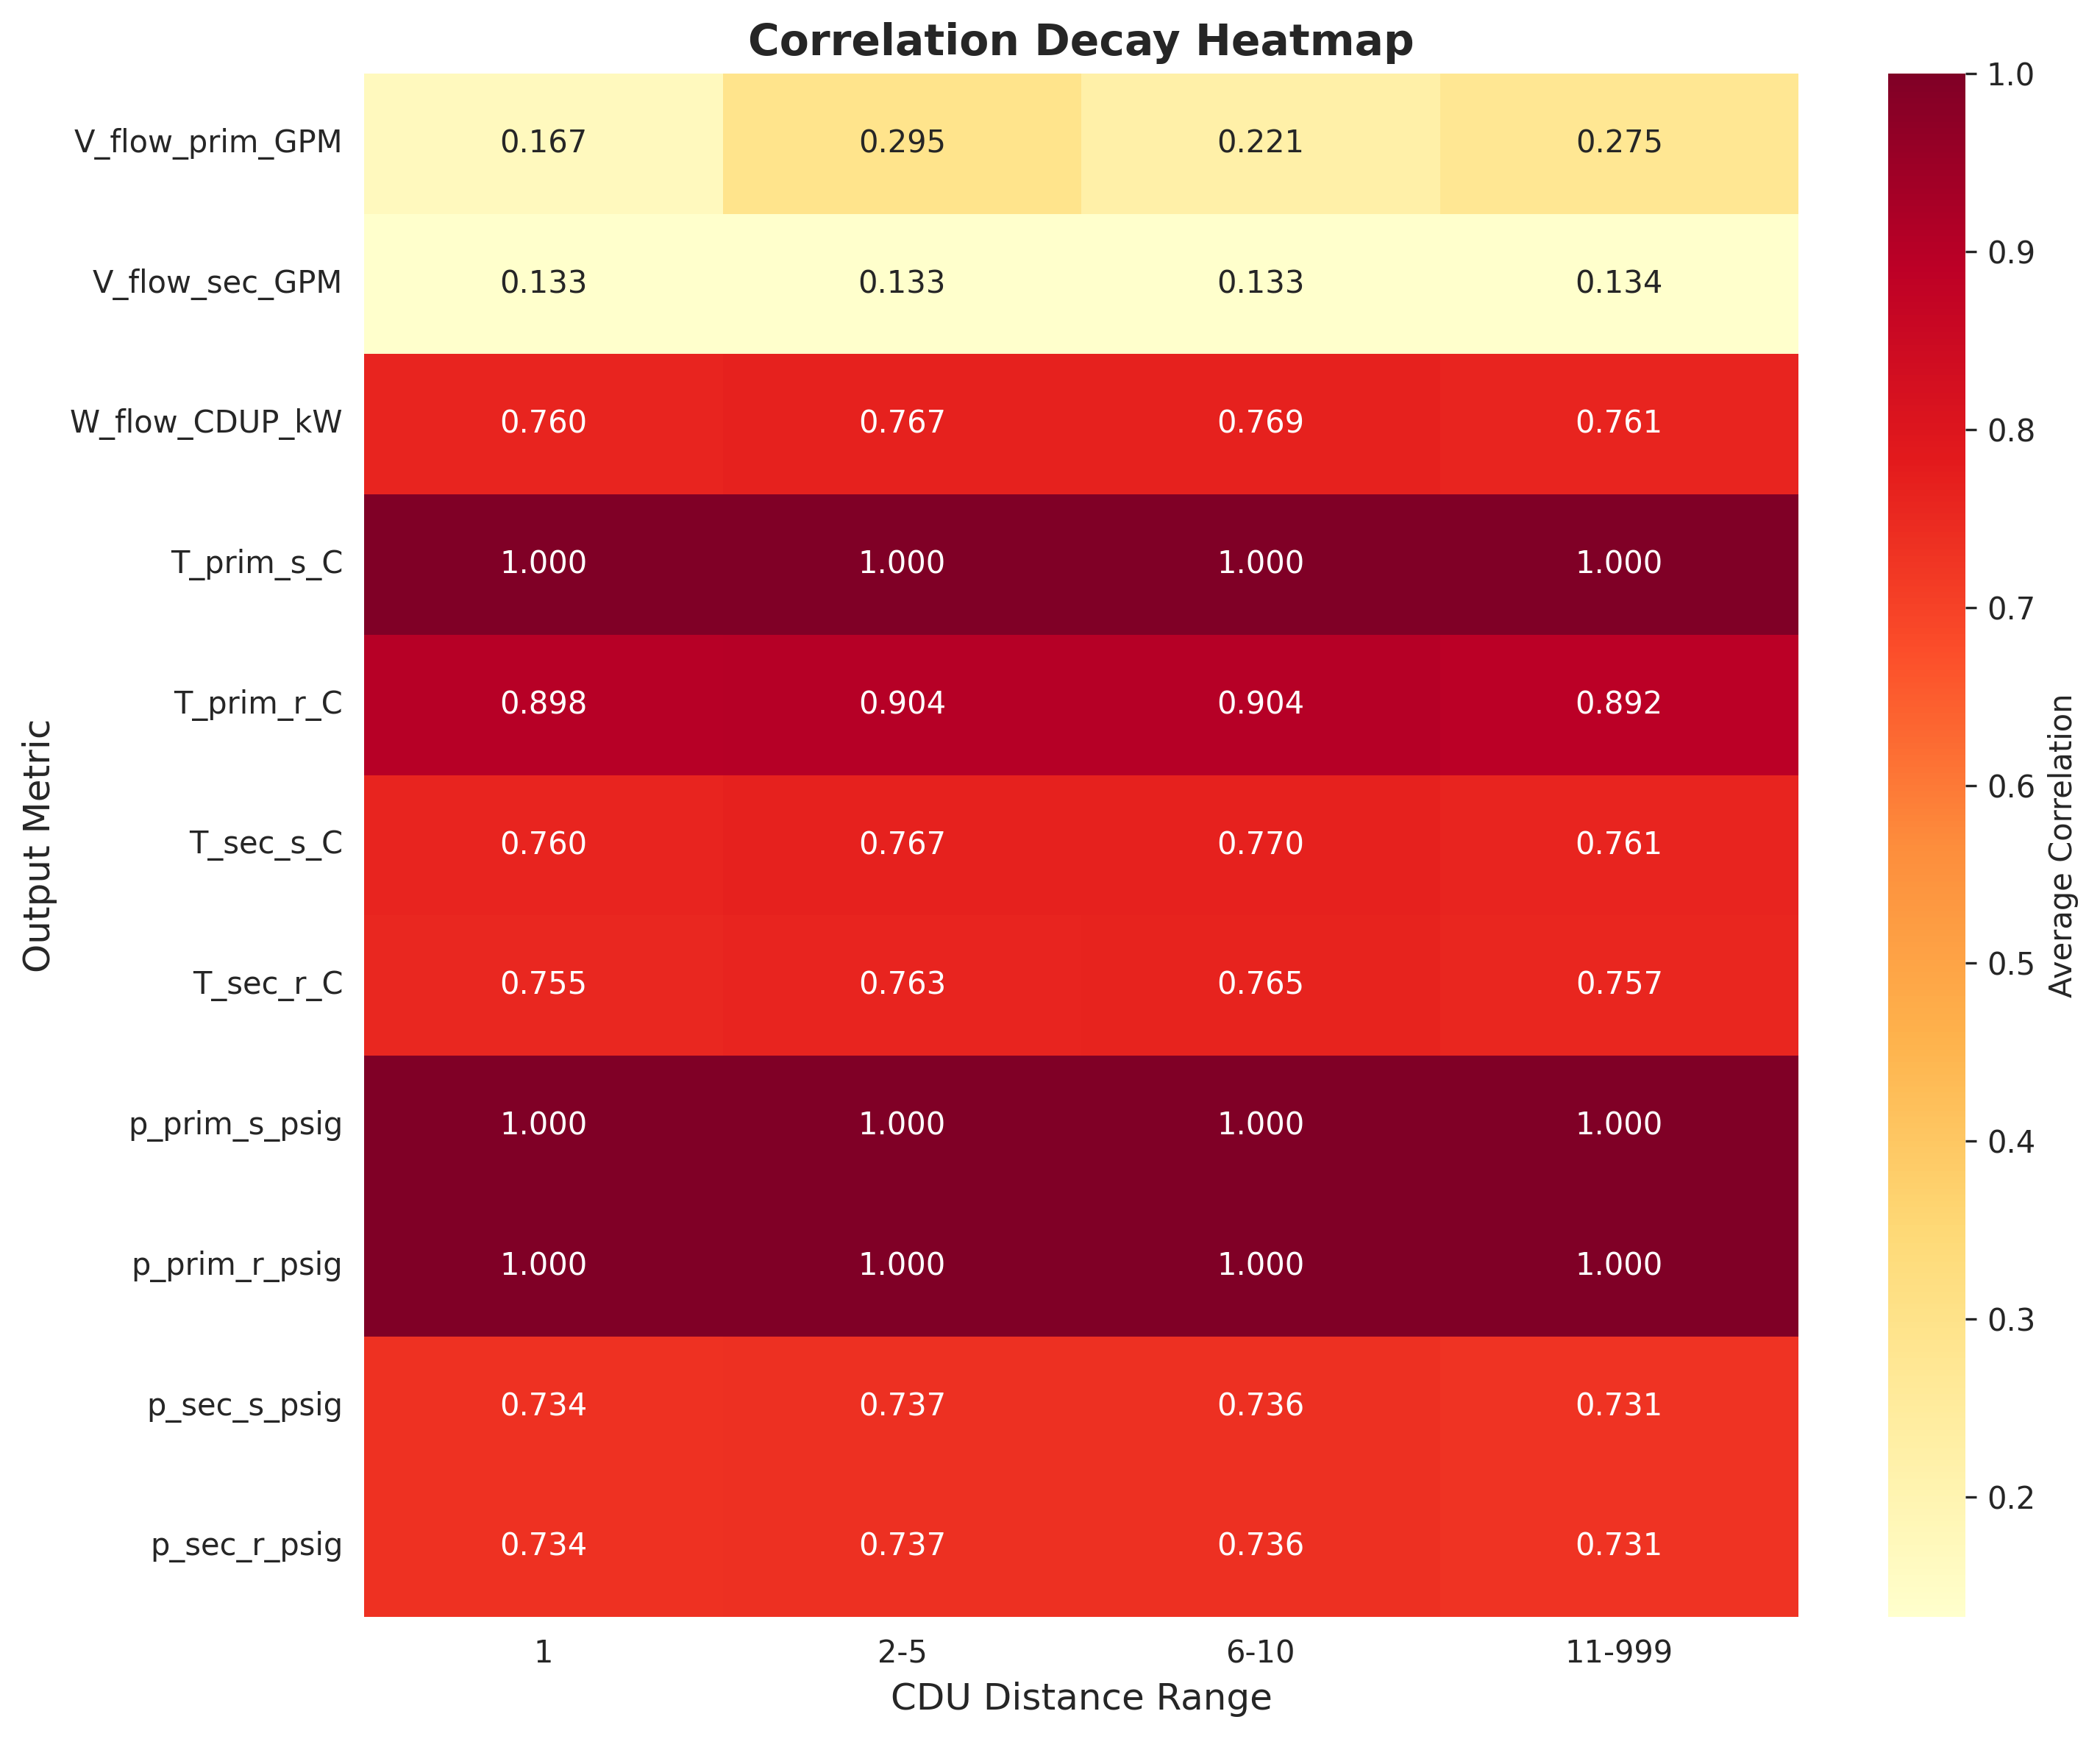

In [35]:
#  Basic Spatial Correlation - All Metrics Analysis
print("\nAnalyzing all metrics...")
all_results = spatial_analyzer.analyze_all_metrics(
    data=df_sim,
    metrics=metrics_to_analyze,
    method='pearson',
    save_dir=BASIC_CORRELATION_DIR
)

# Display correlation decay heatmap
display(Image(filename=f'{BASIC_CORRELATION_DIR}/correlation_decay_heatmap.png'))

In [36]:
# Summary Statistics - Temperature Gradient
print("="*80)
print("SUMMARY STATISTICS")
print("="*80)

# Temperature gradient metrics
if temp_analyzer.n_cdus >= 2:
    inlet_gradients = temp_analyzer.calculate_spatial_gradients(temp_analyzer.data['T_inlet'])
    outlet_gradients = temp_analyzer.calculate_spatial_gradients(temp_analyzer.data['T_outlet'])
    
    inlet_metrics = temp_analyzer.calculate_gradient_metrics(inlet_gradients)
    outlet_metrics = temp_analyzer.calculate_gradient_metrics(outlet_gradients)
    
    print("\n### Temperature Gradient Metrics ###")
    print(f"Inlet  - Mean: {inlet_metrics['mean_magnitude']:.3f}°C, "
          f"Max: {inlet_metrics['max_magnitude']:.3f}°C")
    print(f"Outlet - Mean: {outlet_metrics['mean_magnitude']:.3f}°C, "
          f"Max: {outlet_metrics['max_magnitude']:.3f}°C")
else:
    print("\nTemperature gradient analysis requires at least 2 CDUs")

SUMMARY STATISTICS

### Temperature Gradient Metrics ###
Inlet  - Mean: 8.522°C, Max: 27.027°C
Outlet - Mean: 1.061°C, Max: 10.176°C


In [37]:
# Summary Statistics - Spatial Correlation
print("\n### Spatial Correlation Summary ###")

for metric, result in all_results.items():
    hypothesis = result['hypothesis_results']
    print(f"\n{metric}:")
    print(f"  Correlation range: {hypothesis['correlation_range']} CDUs")
    print(f"  Decay rate: {hypothesis['decay_rate']:.4f}")
    print(f"  Clustering ratio: {hypothesis['clustering_ratio']:.2f}")
    print(f"  Hypothesis supported: {hypothesis['hypothesis_supported']}")


### Spatial Correlation Summary ###

V_flow_prim_GPM:
  Correlation range: 42 CDUs
  Decay rate: -0.0023
  Clustering ratio: 1.10
  Hypothesis supported: False

V_flow_sec_GPM:
  Correlation range: 0 CDUs
  Decay rate: -0.0002
  Clustering ratio: 1.01
  Hypothesis supported: True

W_flow_CDUP_kW:
  Correlation range: 43 CDUs
  Decay rate: -0.0013
  Clustering ratio: 1.02
  Hypothesis supported: True

T_prim_s_C:
  Correlation range: 43 CDUs
  Decay rate: -0.0000
  Clustering ratio: 1.00
  Hypothesis supported: True

T_prim_r_C:
  Correlation range: 43 CDUs
  Decay rate: -0.0031
  Clustering ratio: 1.04
  Hypothesis supported: True

T_sec_s_C:
  Correlation range: 43 CDUs
  Decay rate: -0.0013
  Clustering ratio: 1.02
  Hypothesis supported: True

T_sec_r_C:
  Correlation range: 43 CDUs
  Decay rate: -0.0012
  Clustering ratio: 1.02
  Hypothesis supported: True

p_prim_s_psig:
  Correlation range: 43 CDUs
  Decay rate: -0.0000
  Clustering ratio: 1.00
  Hypothesis supported: True

p_pr